# 공유오피스 무료체험 결제 전환 예측

| PART | 내용 | 산출물 |
|---|---|---|
| 1 | 전처리 & 사용자 피처 생성 + EDA | `user_features.csv` 외 |
| 2 | 파생변수 생성 & 변수 추리기 | `train_visit.csv`, `test_visit.csv`, `feature_config.json` |
| 3 | 결제 전환 예측 모델링 (방문자) | `experiment_log_visit.csv`, `test_result_visit.json` |

> 위에서부터 순서대로 실행한다. 각 PART는 앞 PART가 저장한 파일을 읽어서 시작하므로, 앞 산출물이 있으면 중간 PART부터 실행해도 동작한다.

## Colab 환경 준비 (런타임 연결할 때마다 1번 실행)
CatBoost 설치 + 그래프 한글 폰트(나눔고딕) 설정

In [1]:
!pip install -q catboost
!apt-get -qq install -y fonts-nanum > /dev/null

import logging
import matplotlib.pyplot as plt
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)   # 폰트 경고 숨김
from matplotlib import font_manager
for f in font_manager.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
    font_manager.fontManager.addfont(f)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('준비 완료')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00
준비 완료


## 공통 경로 설정 (Colab)
원본은 팀 공유 폴더 `데이터 원본`에서 **읽기만** 하고, 결과는 **각자 내 드라이브의 `중급2_분석결과/`**에 저장한다.

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

MY_DRIVE = '/content/drive/MyDrive/'

# ============================================================
# 1. 원본 데이터 (팀 공유 폴더 — 읽기 전용)
#    ⚠️ 각자 '파트3_2팀_공유드라이브'를 내 드라이브에 바로가기 추가해야 보임
# ============================================================
RAW_DIR = MY_DRIVE + '파트3_2팀_공유드라이브/데이터 원본/'
assert os.path.isdir(RAW_DIR), f'원본 폴더 없음 (바로가기 추가 확인): {RAW_DIR}'

# ============================================================
# 2. 결과 저장 (각자 내 드라이브 — 팀 폴더에는 저장 안 함)
#    Colab 기본 폴더(/content)는 런타임이 끝나면 지워지므로 내 드라이브에 저장
# ============================================================
OUT_ROOT       = MY_DRIVE + '중급2_분석결과_d3/'
PREP_DIR       = OUT_ROOT + '01_전처리데이터/'
MODEL_DATA_DIR = OUT_ROOT + '02_모델링데이터/'
MODEL_OUT_DIR  = OUT_ROOT + '03_모델링결과/'

for d in [PREP_DIR, MODEL_DATA_DIR, MODEL_OUT_DIR]:
    os.makedirs(d, exist_ok=True)

# 원본 파일 5개 확인
raw_files = ['trial_register.csv', 'trial_payment.csv', 'trial_visit_info.csv',
             'trial_access_log.csv', 'site_area.csv']
missing = [f for f in raw_files if not os.path.exists(RAW_DIR + f)]
assert not missing, f'원본 파일 없음: {missing}'
print('원본 :', RAW_DIR)
print('결과 :', OUT_ROOT)


Mounted at /content/drive
원본 : /content/drive/MyDrive/파트3_2팀_공유드라이브/데이터 원본/
결과 : /content/drive/MyDrive/중급2_분석결과_d3/


---
---
# PART 1. 전처리 & 사용자 피처 생성

## PART 1 개요

**목표**: 원본 5개 테이블을 정제해 **사용자 1명 = 1행**인 모델 입력 데이터(`user_features.csv`)를 만든다.

```
X = 체험기간(day_offset 0~3) 내 이용 행동
y = trial_payment.is_payment (결제 여부)
```

### 분석 기준
| 항목 | 기준 |
|---|---|
| 체험기간 | 신청일부터 3일차까지 (day_offset 0~3) — 전처리·EDA·모델 공통 |
| 타임존 | `trial_access_log.cdate`는 UTC → KST(+9h)로 변환 |
| 결측 시각 | `trial_access_log`로 입·퇴실 시각을 복원하고, 정합성 검사를 통과한 값만 사용 |
| 자정 이어짐 | 23:59:59 퇴실 → 다음날 00:00:00 입실(같은 지점)은 1회 방문으로 병합 |

### 분석 제외 대상
| 사유 | 내용 |
|---|---|
| 신청일 중복 | 신청일이 2개 이상 → 체험기간 특정 불가 |
| 데이터 불일치 | 출입 로그만 있고 방문 기록 없음 |
| 데이터 절단 | `trial_date >= 2023-12-29` → 3일차가 데이터 범위(~2023-12-31) 밖 |
| 시각 복원 불가 | 체험기간 내 입·퇴실 시각 결측이 복원되지 않음 |

### 체험기간을 0~3일로 정의한 이유
- 방문 기록(`trial_visit_info`)에 3일차(day_offset 3)까지 방문이 존재한다.
- 체험기간 전체의 이용 행동을 반영해 고객의 이용 패턴을 파악한다.

### 한계
- 결제 시점 정보가 없어, 3일차 이용 중 일부는 결제 이후 이용일 가능성이 있다.
- `trial_access_log`는 0~2일까지만 존재해, 3일차는 방문·체류 정보만 반영된다.

> 모든 STEP은 `원본 → 문제 확인 → 처리 기준 → 처리 → 처리 전후 비교` 순서로 작성했다.

## 0. 환경 설정
경로와 분석 기준 값을 한곳에 모아둔다.

In [3]:
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option('display.max_columns', 50)

# ---- 경로 ----
DATA_DIR = RAW_DIR       # 원본 csv 폴더 (맨 위 공통 경로 설정)
OUT_DIR  = PREP_DIR      # 결과 저장 폴더

# ---- 분석 기준 ----
EDA_MAX_OFFSET   = 3               # 전처리·EDA 기간: day_offset 0 ~ 3
MODEL_MAX_OFFSET = 3               # 모델 피처 기간: day_offset 0 ~ 3
CUTOFF_DATE      = '2023-12-29'    # 이 날짜 이후 신청자는 3일차가 데이터 범위(~2023-12-31)를 넘으므로 제외
UTC_TO_KST_HOURS = 9               # trial_access_log.cdate 보정값
RESTORE_TOLERANCE_SEC = 60         # 시각 복원 정합성 검사 허용 오차 (체류시간 ≤ 로그 구간 + 60초)

# 전처리 단계별 행 수 기록용
step_log = []
def log(step, table, before, after, note=''):
    step_log.append({'step': step, 'table': table, 'before': before, 'after': after,
                     'diff': after - before, 'note': note})

## 1. 데이터 로드 및 구조 확인
한 행이 무엇을 의미하는지(분석 단위)를 먼저 확인한다.

| 테이블 | 한 행의 의미 |
|---|---|
| trial_register | 사용자 1명의 체험 신청 |
| trial_payment | 사용자 1명의 결제 여부 |
| trial_visit_info | 사용자-지점-날짜 |
| trial_access_log | 출입 이벤트 1건 |
| site_area | 지점 1개 |

In [4]:
register = pd.read_csv(DATA_DIR + 'trial_register.csv')
payment  = pd.read_csv(DATA_DIR + 'trial_payment.csv')
visit    = pd.read_csv(DATA_DIR + 'trial_visit_info.csv')
access   = pd.read_csv(DATA_DIR + 'trial_access_log.csv')
site     = pd.read_csv(DATA_DIR + 'site_area.csv')

raw = {'register': register, 'payment': payment, 'visit': visit, 'access': access, 'site': site}
for name, df in raw.items():
    print(f"[{name}] {df.shape}  고유 user: {df['user_uuid'].nunique() if 'user_uuid' in df else '-'}")
    print('   컬럼:', list(df.columns))

## STEP 1. 데이터 타입 변환

- 날짜/시각 컬럼 → `datetime`
- 체류시간은 `trial_visit_info.stay_time_second`(정수, 초)만 사용하고 문자열 `stay_time`은 버린다.
- 시각 문자열 길이가 섞여 있어서(마이크로초 유무) `format='mixed'`로 변환한다.

### ⚠️ 타임존 확인
명세서에 KST라고 적힌 건 `trial_visit_info`뿐이다. `trial_access_log.cdate`가 UTC인지는 **시간대 분포로 검증**한다.
공유오피스 이용 피크는 보통 오후인데, 만약 `cdate` 피크가 새벽/오전에 있다면 UTC일 가능성이 높다.

In [5]:
register['trial_date'] = pd.to_datetime(register['trial_date'])

visit['date']             = pd.to_datetime(visit['date'])
visit['first_enter_time'] = pd.to_datetime(visit['first_enter_time'], format='mixed')
visit['last_leave_time']  = pd.to_datetime(visit['last_leave_time'],  format='mixed')
visit['stay_time_second'] = pd.to_numeric(visit['stay_time_second'])
visit = visit.drop(columns='stay_time')   # 문자열 체류시간은 사용하지 않음

access['cdate'] = pd.to_datetime(access['cdate'], format='mixed')

# 시각 정밀도를 초 단위로 통일 (소수점 이하 초 버림)
register['trial_date'] = register['trial_date'].dt.as_unit('s')
for col in ['date', 'first_enter_time', 'last_leave_time']:
    visit[col] = visit[col].dt.floor('s').dt.as_unit('s')
access['cdate'] = access['cdate'].dt.floor('s').dt.as_unit('s')
print(register['trial_date'].dtype, visit['first_enter_time'].dtype, access['cdate'].dtype)   # 모두 datetime64[s]면 OK

# 타임존 검증: 두 테이블의 '입실' 시간대 분포 비교
compare = pd.DataFrame({
    'visit_first_enter(KST)': visit['first_enter_time'].dt.hour.value_counts(normalize=True),
    'access_checkin(원본)':   access.loc[access['checkin'] == 1, 'cdate'].dt.hour.value_counts(normalize=True),
}).sort_index().round(3)
compare

datetime64[s] datetime64[s] datetime64[s]


,visit_first_enter(KST),access_checkin(원본)
0.0,0.079,0.036
1.0,0.003,0.048
2.0,0.001,0.050
3.0,0.001,0.072
4.0,0.001,0.100
5.0,0.001,0.101
6.0,0.002,0.104
7.0,0.015,0.090
8.0,0.039,0.081
9.0,0.077,0.073


**확인 포인트**: `access_checkin(원본)` 피크가 `visit_first_enter(KST)`보다 약 9시간 앞서 있으면 UTC다. → 9시간을 더해 KST로 맞춘다.

> 보정 후에도 입실 피크가 visit 13시, access 15시로 약 2시간 차이가 난다. `visit.first_enter_time`은 **하루 첫 입실 1건**이고, `access`의 입실은 **점심·외출 후 재입실까지 모두 포함**해서 access 피크가 오후 쪽으로 밀린다. 또 UTC 그대로 두면 access_log에 신청일보다 하루 앞선 기록(offset −1)이 생기므로(STEP 9에서 확인), KST 보정이 맞다.

In [6]:
access['cdate'] = access['cdate'] + pd.Timedelta(hours=UTC_TO_KST_HOURS)

# 보정 후 피크 시간대 비교
print('visit 입실 피크 시각 :', visit['first_enter_time'].dt.hour.value_counts().idxmax())
print('access 입실 피크 시각:', access.loc[access['checkin'] == 1, 'cdate'].dt.hour.value_counts().idxmax())
visit.dtypes

visit 입실 피크 시각 : 13.0
access 입실 피크 시각: 15


## STEP 2. 완전 중복 제거

| 테이블 | 중복 기준 | 이유 |
|---|---|---|
| trial_register | 전체 컬럼 | 같은 신청이 2번 기록됨 |
| trial_payment | 전체 컬럼 | 같은 결제 여부가 2번 기록됨 |
| trial_visit_info | 전체 컬럼 | 같은 방문 행이 2번 기록됨 |
| trial_access_log | `id` | `id`는 출입 이벤트 고유번호(PK) |

In [7]:
def drop_dup(df, name, subset=None):
    before = len(df)
    df = df.drop_duplicates(subset=subset, keep='first').reset_index(drop=True)
    log('STEP2 완전중복', name, before, len(df), f'기준={subset or "전체 컬럼"}')
    return df

register = drop_dup(register, 'register')
payment  = drop_dup(payment,  'payment')
visit    = drop_dup(visit,    'visit')
access   = drop_dup(access,   'access', subset=['id'])

pd.DataFrame(step_log)

,step,table,before,after,diff,note
0,STEP2 완전중복,register,9659,9631,-28,기준=전체 컬럼
1,STEP2 완전중복,payment,9659,9624,-35,기준=전체 컬럼
2,STEP2 완전중복,visit,11477,11429,-48,기준=전체 컬럼
3,STEP2 완전중복,access,63708,63349,-359,기준=['id']


완전 중복 제거 후에도 **키 기준 중복**이 남아 있는지 다시 확인한다.

In [8]:
print('register  user_uuid 중복:', register['user_uuid'].duplicated().sum())
print('payment   user_uuid 중복:', payment['user_uuid'].duplicated().sum())
print('visit     user+date+site 중복:', visit.duplicated(['user_uuid', 'date', 'site_id']).sum())

# register에 남은 중복 = 신청일이 2개인 사용자
multi_trial = register.groupby('user_uuid')['trial_date'].nunique()
multi_trial_users = multi_trial[multi_trial > 1].index
print('신청일 2개 이상 사용자:', len(multi_trial_users))
register[register['user_uuid'].isin(multi_trial_users)].sort_values('user_uuid')

> **판단**: 명세서에 *'3일 체험은 유저당 1회'*라고 되어 있으므로 신청일이 2개인 사용자는 어느 체험기간 행동이 결제로 이어졌는지 구분할 수 없다. → STEP 6에서 **분석 제외**.
>

## STEP 3. 시각 결측 복원 (`trial_access_log` 활용)

`trial_visit_info`의 입·퇴실 시각 결측은 **2021년 5~6월(수집 초기)**에 몰려 있다. 체류시간(`stay_time_second`)은 모두 남아 있으므로, 같은 날 출입 로그가 있으면 시각을 복원할 수 있다.

**복원 방법** (`같은 사용자 + 날짜(KST) + 지점` 기준)
- 첫 입실 = 입실 기록(`checkin=1`)의 최솟값
- 마지막 퇴실 = 퇴실 기록(`checkin=2`)의 최댓값

**진행 순서**
1. 시각이 정상인 행에 같은 방법을 적용해 **복원 방법 자체의 정확도를 검증**
2. 결측 행 복원 → **정합성 검사** 통과한 값만 채택
3. 복원하지 못한 행은 결측 그대로 둠 → STEP 5에서 해당 사용자 제외

> 부분 중복 집계(STEP 4) **전에** 복원한다. 집계는 `min/max`로 결측을 건너뛰기 때문에, 복원 여부를 먼저 정해야 결측 판정이 정확하다.

In [9]:
# 출입 로그 → 사용자+날짜+지점 단위 입실 최솟값 / 퇴실 최댓값
_a = access.assign(date=access['cdate'].dt.normalize())
keys = ['user_uuid', 'date', 'site_id']
log_span = pd.concat([
    _a[_a['checkin'] == 1].groupby(keys)['cdate'].min().rename('log_enter'),
    _a[_a['checkin'] == 2].groupby(keys)['cdate'].max().rename('log_leave'),
], axis=1).reset_index()

# (1) 복원 방법 검증: 시각이 정상인 행에서 로그로 계산한 값과 실제 값 비교
chk = (visit[visit['first_enter_time'].notna() & visit['last_leave_time'].notna()]
       .merge(log_span, on=keys, how='inner')
       .dropna(subset=['log_enter', 'log_leave']))
diff_in  = (chk['log_enter'] - chk['first_enter_time']).dt.total_seconds().abs()
diff_out = (chk['log_leave'] - chk['last_leave_time']).dt.total_seconds().abs()

print(f'검증 대상(정상 행 중 로그가 있는 행): {len(chk)}')
pd.DataFrame({
    '입실 일치율': [(diff_in <= s).mean() for s in [60, 600, 3600]],
    '퇴실 일치율': [(diff_out <= s).mean() for s in [60, 600, 3600]],
}, index=['1분 이내', '10분 이내', '1시간 이내']).round(3)

검증 대상(정상 행 중 로그가 있는 행): 8413


,입실 일치율,퇴실 일치율
1분 이내,0.939,0.921
10분 이내,0.947,0.927
1시간 이내,0.960,0.944


> **판단 기준**: 1분 이내 일치율이 90% 이상이면 복원 방법을 신뢰할 수 있다고 본다. 일치하지 않는 일부를 걸러내기 위해 아래에서 정합성 검사를 한 번 더 한다.

In [10]:
before_missing = (visit['first_enter_time'].isna() | visit['last_leave_time'].isna()).sum()
visit = visit.merge(log_span, on=keys, how='left')

miss     = visit['first_enter_time'].isna() | visit['last_leave_time'].isna()
has_in   = visit['log_enter'].notna()
has_out  = visit['log_leave'].notna()
span_sec = (visit['log_leave'] - visit['log_enter']).dt.total_seconds()

# 정합성 검사: 퇴실 > 입실, 체류시간 ≤ 로그 구간 + 허용 오차
consistent = has_in & has_out & (span_sec > 0) & (visit['stay_time_second'] <= span_sec + RESTORE_TOLERANCE_SEC)

status = np.select(
    [miss & consistent, miss & has_in & has_out, miss & (has_in | has_out), miss],
    ['복원', '불일치(복원 X)', '부분 로그(복원 X)', '로그 없음(복원 X)'],
    default='정상')

restore = miss & consistent
visit.loc[restore, 'first_enter_time'] = visit.loc[restore, 'log_enter']
visit.loc[restore, 'last_leave_time']  = visit.loc[restore, 'log_leave']
visit['time_restored'] = restore.astype(int)
visit = visit.drop(columns=['log_enter', 'log_leave'])

after_missing = (visit['first_enter_time'].isna() | visit['last_leave_time'].isna()).sum()
log('STEP3 시각 복원', 'visit(결측 행)', before_missing, after_missing, f'복원 {restore.sum()}행')

print('[결측 행 처리 결과]')
print(pd.Series(status[miss.values]).value_counts().to_string())
print(f'\n결측 행: {before_missing} → {after_missing}  (복원 {restore.sum()}행)')
print('복원 행의 월 분포:', visit.loc[restore, 'date'].dt.to_period('M').value_counts().sort_index().to_dict())

[결측 행 처리 결과]
복원             395
불일치(복원 X)       78
로그 없음(복원 X)     65
부분 로그(복원 X)     17

결측 행: 555 → 160  (복원 395행)
복원 행의 월 분포: {Period('2021-05', 'M'): 145, Period('2021-06', 'M'): 250}


> 복원 불가 행(불일치·부분 로그·로그 없음)은 **값을 억지로 채우지 않고 결측으로 남긴다.** 이 행을 가진 사용자는 STEP 5에서 제외된다. 복원된 행은 `time_restored = 1`로 표시해서, 나중에 복원 사용자를 빼고도 결과가 같은지(민감도) 확인할 수 있게 한다.

## STEP 4. 부분 중복 처리 (사용자+날짜+지점)
완전 중복을 지워도 같은 `user_uuid + date + site_id`가 여러 행인 경우가 남는다. 예시를 보면 **같은 날 시간 구간이 이어지거나 따로 떨어진 방문 조각**이다 (값이 서로 다름 → 단순 중복 아님).

**처리 기준**: 하나의 사용자-지점-날짜 행으로 집계
- `stay_time_second` → 합계 / `first_enter_time` → 최솟값 / `last_leave_time` → 최댓값
- 이 집계를 자정 병합(STEP 8) **전에** 해야 00:00:00 입실·23:59:59 퇴실 판정이 정확해진다.
- ⚠️ `min/max`는 결측을 건너뛰므로, 집계 **전에** 시각 결측 플래그(`time_missing`)를 먼저 만들어 둔다. (조각 중 하나라도 결측이면 결측으로 표시)

In [11]:
# 집계하면 결측이 가려지므로 먼저 플래그 생성
visit['time_missing'] = (visit['first_enter_time'].isna() | visit['last_leave_time'].isna()).astype(int)

dup_mask = visit.duplicated(['user_uuid', 'date', 'site_id'], keep=False)
print('부분 중복 행:', dup_mask.sum())
display(visit[dup_mask].sort_values(['user_uuid', 'date', 'first_enter_time']).head(6))

before = len(visit)
visit = (visit.groupby(['user_uuid', 'date', 'site_id'], as_index=False)
              .agg(first_enter_time=('first_enter_time', 'min'),
                   last_leave_time=('last_leave_time', 'max'),
                   stay_time_second=('stay_time_second', 'sum'),
                   time_missing=('time_missing', 'max'),
                   time_restored=('time_restored', 'max')))   # 조각 중 하나라도 복원이면 1
log('STEP4 부분중복 집계', 'visit', before, len(visit), 'user+date+site 1행')

assert not visit.duplicated(['user_uuid', 'date', 'site_id']).any()
print('집계 후 행 수:', len(visit))

부분 중복 행: 76


집계 후 행 수: 11389


## STEP 5. 결측 사용자 판정

- 결측은 `trial_visit_info.first_enter_time / last_leave_time`에만 있다.
- STEP 3에서 `access_log`로 복원할 수 있는 값은 이미 복원했다. 여기서 확인하는 건 **복원 후에도 남은 결측**이다.
- **처리 기준**: 체험기간(day_offset 0~3) 안에 **복원 불가** 결측 행이 남은 사용자를 제외한다.
  - 행만 삭제하면 체류시간이 있는 실제 방문자가 '미방문자'로 잘못 분류되고, 행을 유지하면 시간대 변수가 불완전해지므로 사용자 단위로 제외한다.

In [12]:
for name, df in {'register': register, 'payment': payment, 'visit': visit, 'access': access}.items():
    na = df.isna().sum()
    print(f'[{name}]', dict(na[na > 0]) or '결측 없음')

# 체험기간(0~EDA_MAX_OFFSET) 안의 결측만 대상으로 판정
_trial = register.drop_duplicates('user_uuid')[['user_uuid', 'trial_date']]
_v = visit.merge(_trial, on='user_uuid', how='left')
_v['day_offset'] = (_v['date'] - _v['trial_date']).dt.days
in_eda = _v['day_offset'].between(0, EDA_MAX_OFFSET)

time_missing_users = _v.loc[in_eda & (_v['time_missing'] == 1), 'user_uuid'].unique()
print('\n체험기간 내 결측 행:', (in_eda & (_v['time_missing'] == 1)).sum())
print('복원 불가 결측 보유 사용자 (→ STEP 6에서 제외):', len(time_missing_users))

restored_users = _v.loc[in_eda & (_v['time_restored'] == 1), 'user_uuid'].unique()
restored_users = [u for u in restored_users if u not in set(time_missing_users)]
print('복원으로 살린 사용자 (분석에 포함):', len(restored_users))

# 참고: 제외 대상의 결제율 (보고서 한계 기록용)
_pay = payment.drop_duplicates('user_uuid').set_index('user_uuid')['is_payment']
print('복원 사용자 결제율:', round(_pay.reindex(restored_users).mean(), 4))
print('제외 대상 결제율:', round(_pay.reindex(time_missing_users).mean(), 4),
      '/ 전체 결제율:', round(_pay.mean(), 4))

[register] 결측 없음
[payment] 결측 없음
[visit] {'first_enter_time': np.int64(160), 'last_leave_time': np.int64(160)}
[access] 결측 없음

체험기간 내 결측 행: 160
복원 불가 결측 보유 사용자 (→ STEP 6에서 제외): 129
복원으로 살린 사용자 (분석에 포함): 203
복원 사용자 결제율: 0.5025
제외 대상 결제율: 0.5271 / 전체 결제율: 0.3795


> 제외 대상과 복원된 사용자 모두 **2021년 5~6월 초기 고객**이다. 두 그룹의 결제율이 비슷하면 제외로 인한 추가 편향은 작다. 초기 고객의 결제율이 전체보다 높다는 점은 **분석 대상의 특성**으로 보고서에 기록한다.

## STEP 6. 테이블 간 정합성 확인 + 제외 대상 정리

제외 대상은 삭제 이유와 함께 `excluded_users`에 따로 저장한다. (나중에 보고서에서 "왜 N명이 빠졌는가" 설명용)

| 제외 사유 | 이유 |
|---|---|
| `multi_trial_date` | 1인 1회 체험 원칙 위배, 체험기간 특정 불가 |
| `access_only` | 출입 기록은 있는데 방문 기록이 없음 → 데이터 불일치 |
| `data_cutoff` | `trial_date >= 2023-12-29` → 3일차가 데이터 끝(2023-12-31)을 넘어 행동이 잘림 |
| `time_missing` | 체험기간 내 **복원 불가** 입·퇴실 시각 결측 행 보유 (STEP 3, 5) |

In [13]:
reg_users   = set(register['user_uuid'])
pay_users   = set(payment['user_uuid'])
visit_users = set(visit['user_uuid'])
acc_users   = set(access['user_uuid'])

print('register == payment 사용자 집합:', reg_users == pay_users)
print('visit에만 있고 register에 없음 :', len(visit_users - reg_users))
print('access에만 있고 register에 없음:', len(acc_users - reg_users))
print('access엔 있는데 visit엔 없음   :', len(acc_users - visit_users))
print('visit엔 있는데 access엔 없음   :', len(visit_users - acc_users), '(출입 로그 누락 → 제외하지 않고 access 변수만 0)')

register == payment 사용자 집합: True
visit에만 있고 register에 없음 : 0
access에만 있고 register에 없음: 0
access엔 있는데 visit엔 없음   : 3
visit엔 있는데 access엔 없음   : 511 (출입 로그 누락 → 제외하지 않고 access 변수만 0)


In [14]:
access_only_users = list(acc_users - visit_users)
first_trial = register.drop_duplicates('user_uuid')          # 사유 판정용 신청일
cutoff_users = first_trial.loc[first_trial['trial_date'] >= CUTOFF_DATE, 'user_uuid']

excluded = pd.concat([
    pd.DataFrame({'user_uuid': list(multi_trial_users),  'reason': 'multi_trial_date'}),
    pd.DataFrame({'user_uuid': access_only_users,        'reason': 'access_only'}),
    pd.DataFrame({'user_uuid': list(cutoff_users),       'reason': 'data_cutoff'}),
    pd.DataFrame({'user_uuid': list(time_missing_users), 'reason': 'time_missing'}),
])
# 한 사용자가 여러 사유에 걸리면 사유를 합쳐서 1행으로
excluded_users = excluded.groupby('user_uuid')['reason'].agg(lambda x: '|'.join(sorted(x))).reset_index()
print(excluded_users['reason'].value_counts())
print('총 제외 사용자:', len(excluded_users))

reason
time_missing        129
data_cutoff          27
multi_trial_date      7
access_only           3
Name: count, dtype: int64
총 제외 사용자: 166


## STEP 7. 신청자 기준 사용자 테이블 (`users`)
`register` + `payment`를 `user_uuid`로 1:1 결합한다. 이 테이블이 **최종 데이터마트의 뼈대**(모든 left join의 기준)다.

In [15]:
excl_set = set(excluded_users['user_uuid'])

before = register['user_uuid'].nunique()
users = (register[~register['user_uuid'].isin(excl_set)]
         .merge(payment, on='user_uuid', how='left', validate='one_to_one'))
log('STEP7 제외', 'users', before, len(users), '제외 대상 반영')

assert users['user_uuid'].is_unique
assert users['is_payment'].notna().all()
print(users.shape)
print('결제율:', round(users['is_payment'].mean(), 4))
users.head()

(9458, 3)
결제율: 0.3776


## STEP 8. 자정 이어짐 처리 (체험기간 필터보다 **먼저** 수행)

`trial_visit_info`는 날짜 단위로 행이 잘려 있어서, 자정을 넘긴 한 번의 이용이 2행으로 쪼개진다.

```
행1: 5/1  23:00 입실 ~ 5/1 23:59:59 퇴실
행2: 5/2  00:00:00 입실 ~ 5/2 01:00 퇴실   → 실제로는 1회 방문
```

**판정 조건** (모두 만족하면 이전 행에 이어 붙임)
1. 같은 사용자, 같은 지점
2. 이전 행 `last_leave_time` = 23:59:59, 현재 행 `first_enter_time` = 00:00:00
3. 날짜 차이 = 1일

**왜 필터보다 먼저?** 필터를 먼저 하면 체험기간 경계에 걸친 방문의 뒷부분이 잘려 체류시간이 과소 계산될 수 있다. 병합 후 **방문 시작일** 기준으로 체험기간을 판정한다. (원본 방문 기록은 day_offset 3까지만 있어 실제로 잘리는 방문은 없다)

**방문일 기준**: 병합된 방문은 **시작일에만** 방문한 것으로 센다. 자정을 넘겨 다음 날까지 이어진 경우, 다음 날은 `visit_days`·`visited_d*`에 따로 잡히지 않는다.

결과 테이블 `sessions`: **한 행 = 1회 방문(사용자-지점-방문 시작일)**

In [16]:
v = visit.sort_values(['user_uuid', 'site_id', 'date']).reset_index(drop=True)
g = v.groupby(['user_uuid', 'site_id'])

prev_leave = g['last_leave_time'].shift()
prev_date  = g['date'].shift()

is_cont = (
    (v['first_enter_time'].dt.strftime('%H:%M:%S') == '00:00:00') &
    (prev_leave.dt.strftime('%H:%M:%S') == '23:59:59') &
    ((v['date'] - prev_date).dt.days == 1)
)
v['session_id'] = (~is_cont).cumsum()   # 이어지는 행은 같은 session_id
print('자정 이어짐으로 병합되는 행:', is_cont.sum())

sessions = (v.groupby('session_id')
              .agg(user_uuid=('user_uuid', 'first'),
                   site_id=('site_id', 'first'),
                   visit_date=('date', 'min'),                 # 방문 시작일
                   first_enter_time=('first_enter_time', 'min'),
                   last_leave_time=('last_leave_time', 'max'),
                   stay_time_second=('stay_time_second', 'sum'),
                   n_rows=('date', 'size'),
                   time_restored=('time_restored', 'max'))
              .reset_index(drop=True))
log('STEP8 자정병합', 'visit→sessions', len(visit), len(sessions))

# 처리 전후 비교: 00시 입실 비중이 크게 줄어야 정상
print('00시 입실 행 (병합 전):', (v['first_enter_time'].dt.hour == 0).sum())
print('00시 입실 행 (병합 후):', (sessions['first_enter_time'].dt.hour == 0).sum())
sessions[sessions['n_rows'] > 1].head()

자정 이어짐으로 병합되는 행: 605
00시 입실 행 (병합 전): 857
00시 입실 행 (병합 후): 252


## STEP 9. 체험기간 정의 및 필터링

```
day_offset = 방문 시작일 - trial_date
체험기간   = 0 ≤ day_offset ≤ 3   (전처리·EDA·모델 공통)
```

### 🔎 필터 전에 분포부터 본다

In [17]:
sessions = sessions.merge(users[['user_uuid', 'trial_date']], on='user_uuid', how='inner')  # 제외 대상 자동 제거
sessions['day_offset'] = (sessions['visit_date'] - sessions['trial_date']).dt.days

dist = sessions['day_offset'].value_counts().sort_index()
print(dist.to_string())
print('\n음수 offset(신청 전 방문):', (sessions['day_offset'] < 0).sum())

day_offset
0    1590
1    3914
2    2959
3    2013

음수 offset(신청 전 방문): 0


> `trial_visit_info`에는 `day_offset = 3` 방문이 꽤 있다. 아래에서 `trial_access_log`의 offset 분포와 3일차 방문자의 결제율을 함께 확인한다.

In [18]:
# (1) access_log는 어떤 기간까지 기록되어 있나? (KST 보정 후)
_acc = access.merge(users[['user_uuid', 'trial_date']], on='user_uuid')
print('[access_log day_offset 분포]')
print(((_acc['cdate'].dt.normalize() - _acc['trial_date']).dt.days).value_counts().sort_index().to_string())

# (2) offset 3에 방문한 사용자는 결제율이 다른가?
has_d3 = sessions.loc[sessions['day_offset'] == 3, 'user_uuid'].unique()
chk = users.assign(visit_d3=users['user_uuid'].isin(has_d3).astype(int))
print('\n[offset 3 방문 여부별 결제율]')
print(chk.groupby('visit_d3')['is_payment'].agg(['count', 'mean']).round(4))

[access_log day_offset 분포]
0    10644
1    28859
2    22427

[offset 3 방문 여부별 결제율]
          count    mean
visit_d3               
0          7459  0.3450
1          1999  0.4992


**해석 포인트**
- `access_log`는 offset 0~2에만 기록되어 있다. (UTC 그대로 두면 offset -1이 생긴다 → KST 보정이 맞다는 근거)
- 방문 기록에는 3일차 방문이 존재하므로, 체험기간을 **0~3일**로 정의해 이용 행동을 모두 반영한다.
- 3일차 방문자의 결제율이 높게 나타난다. 결제 시점 정보가 없어 결제 이후 이용과 구분할 수 없으므로, 이 점은 **한계**로 기록한다.

In [19]:
before = len(sessions)
out_of_trial = sessions[~sessions['day_offset'].between(0, EDA_MAX_OFFSET)]
sessions = sessions[sessions['day_offset'].between(0, EDA_MAX_OFFSET)].reset_index(drop=True)
log('STEP9 체험기간 필터', 'sessions', before, len(sessions), f'day_offset 0~{EDA_MAX_OFFSET} ')

# 모델 기간 여부 표시 (EDA 파일에서도 바로 구분 가능하도록)
sessions['in_model_window'] = (sessions['day_offset'] <= MODEL_MAX_OFFSET).astype(int)

print('제외된 방문:', len(out_of_trial), '/ 남은 방문:', len(sessions))
print('체험기간(0~3) 내 방문 사용자:', sessions['user_uuid'].nunique())
print('모델 기간(0~3) 내 방문 사용자:', sessions.loc[sessions['in_model_window'] == 1, 'user_uuid'].nunique())

제외된 방문: 0 / 남은 방문: 10476
체험기간(0~3) 내 방문 사용자: 6377
모델 기간(0~3) 내 방문 사용자: 6377


## STEP 10. 체류시간 이상치 확인
**삭제하지 않고 확인만** 한다. 24시간 운영 공유오피스라 긴 체류도 가능하다.
- `stay_time_second <= 0` → 오류 후보
- 병합 후 24시간 초과 → 자정 병합이 여러 날 연결된 경우인지 확인

In [20]:
print(sessions['stay_time_second'].describe().round(0))
print('\n0초 이하:', (sessions['stay_time_second'] <= 0).sum())
print('60초 미만(찍고 나간 수준):', (sessions['stay_time_second'] < 60).sum())
print('24시간 초과:', (sessions['stay_time_second'] > 86400).sum())

# 트리 모델은 극단값에 강하지만, 로지스틱 회귀용으로 쓸 때를 대비해 플래그만 남긴다
sessions['short_visit'] = (sessions['stay_time_second'] < 60).astype(int)

count     10476.0
mean      17665.0
std       14163.0
min           4.0
25%        8177.0
50%       15066.0
75%       23744.0
max      249203.0
Name: stay_time_second, dtype: float64

0초 이하: 0
60초 미만(찍고 나간 수준): 19
24시간 초과: 49


> **판단 기준**: 0 이하가 없고 24시간 초과도 거의 없다면 원본 시각 구조상 설명 가능한 값이므로 유지한다. 극단값 처리는 모델별로(로지스틱 회귀 → log 변환 등) 모델링 단계에서 결정한다.

## STEP 11. 방문 단위 파생변수

| 변수 | 정의 |
|---|---|
| `stay_hour` | `stay_time_second / 3600` |
| `entry_hour` | `first_enter_time`의 시(hour) |
| `time_band` | 입실 시간대 (4구간: 심야 0~5 / 오전 6~11 / 오후 12~17 / 저녁 18~23) |
| `is_weekend` | 방문 시작일이 토/일 |

In [21]:
sessions['stay_hour']  = sessions['stay_time_second'] / 3600
sessions['entry_hour'] = sessions['first_enter_time'].dt.hour
sessions['is_weekend'] = (sessions['visit_date'].dt.dayofweek >= 5).astype(int)

bins   = [-1, 5, 11, 17, 23]
labels = ['심야', '오전', '오후', '저녁']
sessions['time_band'] = pd.cut(sessions['entry_hour'], bins=bins, labels=labels)

assert sessions['time_band'].notna().all(), '시각 결측 사용자를 제외했으므로 불명이 없어야 함'
sessions['time_band'].value_counts()

,count
time_band,
오후,5360
오전,3126
저녁,1681
심야,309


## STEP 12. 사용자-날짜 단위 집계 (`user_daily`)
**한 행 = 사용자 1명의 하루 이용.** 같은 날 여러 지점을 가도 방문일은 1일이다. (체험기간 0~3일)

In [22]:
user_daily = (sessions.groupby(['user_uuid', 'visit_date', 'day_offset'])
                .agg(total_stay_hour=('stay_hour', 'sum'),
                     first_enter=('first_enter_time', 'min'),
                     last_leave=('last_leave_time', 'max'),
                     n_sites=('site_id', 'nunique'),
                     n_sessions=('site_id', 'size'))
                .reset_index())
user_daily['in_model_window'] = (user_daily['day_offset'] <= MODEL_MAX_OFFSET).astype(int)
print(user_daily.shape)
print('하루에 2개 이상 지점 방문한 사용자-날짜:', (user_daily['n_sites'] > 1).sum())
user_daily.head()

(10410, 9)
하루에 2개 이상 지점 방문한 사용자-날짜: 63


## STEP 13. `trial_access_log` 체험기간 필터
KST 보정한 `cdate`의 날짜로 `day_offset`을 계산해 체험기간(0~3)으로 자른다.

> 원본 출입 기록은 day_offset 0~2에만 있어 필터로 제거되는 이벤트는 없다. 따라서 **3일차(offset 3)는 출입 변수 없이 방문·체류 정보만 반영**된다.

In [23]:
acc = access.merge(users[['user_uuid', 'trial_date']], on='user_uuid', how='inner')
acc['day_offset'] = (acc['cdate'].dt.normalize() - acc['trial_date']).dt.days

before = len(acc)
acc = acc[acc['day_offset'].between(0, EDA_MAX_OFFSET)].reset_index(drop=True)
acc['in_model_window'] = (acc['day_offset'] <= MODEL_MAX_OFFSET).astype(int)
log('체험기간 필터', 'access', before, len(acc), f'day_offset 0~{EDA_MAX_OFFSET}')
print('체험기간 내 출입 이벤트:', len(acc))
print(acc['day_offset'].value_counts().sort_index().to_string())
print(acc['checkin'].value_counts().rename({1: '입실', 2: '퇴실'}))

체험기간 내 출입 이벤트: 61930
day_offset
0    10644
1    28859
2    22427
checkin
입실    31258
퇴실    30672
Name: count, dtype: int64


## STEP 14. 사용자 단위 피처 생성 (체험기간 0~3일)

체험기간(0~3일) 데이터로 사용자 단위 피처를 만든다.

| 그룹 | 변수 |
|---|---|
| 방문 지속성 | `visit_days`, `visit_sessions`, `revisit`, `first_visit_offset`, `last_visit_offset`, `visit_span`, `visited_d0~d3` |
| 이용시간 | `total_stay_hour`, `avg_stay_hour_per_day`, `max_stay_hour`, `first_day_stay_hour`, `short_visit_count` |
| 이용 빈도 | `access_count`, `entry_count`, `exit_count`, `entries_per_day`, `entry_exit_gap` |
| 이용 시간대 | `first_entry_hour`, `avg_entry_hour`, `evening_entry_count`, `band_*` |
| 지점 | `n_sites`, `main_site_id`, `main_site_area` |
| 기타 | `weekend_visit_days` |
| 민감도 확인용 (모델 피처 아님) | `time_restored_user` — 시각 복원 행 보유 여부 |
| 신청 시점 정보 | `trial_dow`, `trial_is_weekend`, `trial_month` (신청 시점에 알 수 있는 정보) |

In [24]:
# 모델 기간(0~3일) 데이터 사용
s_m = sessions[sessions['day_offset'] <= MODEL_MAX_OFFSET]
d_m = user_daily[user_daily['day_offset'] <= MODEL_MAX_OFFSET]
a_m = acc[acc['day_offset'] <= MODEL_MAX_OFFSET]
print('모델 기간 방문:', len(s_m), '/ 사용자-날짜:', len(d_m), '/ 출입 이벤트:', len(a_m))

# --- (1) 방문 지속성 + 이용시간 (user_daily 기준) ---
f_daily = d_m.groupby('user_uuid').agg(
    visit_days=('visit_date', 'nunique'),
    first_visit_offset=('day_offset', 'min'),
    last_visit_offset=('day_offset', 'max'),
    total_stay_hour=('total_stay_hour', 'sum'),
    max_stay_hour=('total_stay_hour', 'max'),
)
f_daily['revisit'] = (f_daily['visit_days'] >= 2).astype(int)
f_daily['visit_span'] = f_daily['last_visit_offset'] - f_daily['first_visit_offset']
f_daily['avg_stay_hour_per_day'] = f_daily['total_stay_hour'] / f_daily['visit_days']

# 첫 방문일 체류시간
first_day = d_m.sort_values('visit_date').drop_duplicates('user_uuid')
f_daily['first_day_stay_hour'] = first_day.set_index('user_uuid')['total_stay_hour']

# 체험 n일차 방문 여부 (visited_d0, visited_d1, ...)
day_flag = (pd.crosstab(d_m['user_uuid'], d_m['day_offset'])
              .clip(upper=1)
              .reindex(columns=range(MODEL_MAX_OFFSET + 1), fill_value=0)
              .add_prefix('visited_d'))

# --- (2) 방문(session) 기준 변수 ---
f_sess = s_m.groupby('user_uuid').agg(
    visit_sessions=('site_id', 'size'),
    n_sites=('site_id', 'nunique'),
    avg_entry_hour=('entry_hour', 'mean'),
    short_visit_count=('short_visit', 'sum'),
)
f_sess['first_entry_hour'] = (s_m.sort_values(['visit_date', 'first_enter_time'])
                                      .drop_duplicates('user_uuid')
                                      .set_index('user_uuid')['entry_hour'])
f_sess['evening_entry_count'] = s_m[s_m['entry_hour'] >= 18].groupby('user_uuid').size()
f_sess['weekend_visit_days'] = (s_m[s_m['is_weekend'] == 1]
                                  .groupby('user_uuid')['visit_date'].nunique())

# 시간대별 방문 비율
band = (pd.crosstab(s_m['user_uuid'], s_m['time_band'], normalize='index')
          .add_prefix('band_'))

# 주 이용 지점 = 체류시간이 가장 긴 지점
main_site = (s_m.groupby(['user_uuid', 'site_id'])['stay_hour'].sum()
               .reset_index().sort_values('stay_hour', ascending=False)
               .drop_duplicates('user_uuid')
               .merge(site, on='site_id', how='left')
               .set_index('user_uuid')[['site_id', 'area_pyeong']]
               .rename(columns={'site_id': 'main_site_id', 'area_pyeong': 'main_site_area'}))

# --- (3) 출입 로그 변수 ---
f_acc = a_m.groupby('user_uuid').agg(
    access_count=('id', 'size'),
    entry_count=('checkin', lambda x: (x == 1).sum()),
    exit_count=('checkin', lambda x: (x == 2).sum()),
)
f_acc['entry_exit_gap'] = f_acc['entry_count'] - f_acc['exit_count']   # 미퇴실(태그 누락) 정도

visit_feat = pd.concat([f_daily, day_flag, f_sess, band, main_site, f_acc], axis=1)
visit_feat.index.name = 'user_uuid'
visit_feat = visit_feat.reset_index()
print(visit_feat.shape)
visit_feat.head()

모델 기간 방문: 10476 / 사용자-날짜: 10410 / 출입 이벤트: 61930
(6377, 31)


## STEP 15. 미방문자 처리 + 최종 결합

`users`(신청자 전체) 기준 **left join** → 미방문자도 행을 유지한다. *미방문 자체가 중요한 행동 정보*다.

| 변수 유형 | 미방문자 값 | 이유 |
|---|---|---|
| 횟수·시간·플래그 (`visit_days`, `total_stay_hour`, `access_count` ...) | `0` | 실제로 0회/0시간 |
| 방문해야 정의되는 값 (`first_visit_offset`, `first_entry_hour`, `main_site_id` ...) | `NaN` 유지 | 0을 넣으면 "0시 입실", "신청일 방문"으로 잘못 읽힘 |

In [25]:
df = users.merge(visit_feat, on='user_uuid', how='left', validate='one_to_one')

df['visited'] = df['visit_days'].notna().astype(int)

zero_cols = (['visit_days', 'visit_sessions', 'revisit', 'total_stay_hour', 'max_stay_hour',
              'avg_stay_hour_per_day', 'first_day_stay_hour', 'short_visit_count', 'n_sites',
              'evening_entry_count', 'weekend_visit_days',
              'access_count', 'entry_count', 'exit_count', 'entry_exit_gap']
             + [c for c in df.columns if c.startswith('visited_d') or c.startswith('band_')])
df[zero_cols] = df[zero_cols].fillna(0)

# 방문일당 입실 횟수 (방문자만 계산, 미방문자는 0)
df['entries_per_day'] = np.where(df['visit_days'] > 0, df['entry_count'] / df['visit_days'].replace(0, np.nan), 0)
# 방문했지만 출입 로그가 없는 사용자 표시 (로그 누락)
df['access_log_missing'] = ((df['visited'] == 1) & (df['access_count'] == 0)).astype(int)

# 시각 복원 사용자 플래그 (민감도 확인용, 모델 피처로 쓰지 않음 → PART 2 ID_COLS에서 제외)
df['time_restored_user'] = df['user_uuid'].isin(sessions.loc[sessions['time_restored'] == 1, 'user_uuid']).astype(int)

# 신청 시점 정보
df['trial_dow'] = df['trial_date'].dt.dayofweek
df['trial_is_weekend'] = (df['trial_dow'] >= 5).astype(int)
df['trial_month'] = df['trial_date'].dt.month

# 정수형 정리
int_cols = [c for c in zero_cols if c not in ['total_stay_hour', 'max_stay_hour', 'avg_stay_hour_per_day',
                                             'first_day_stay_hour'] and not c.startswith('band_')]
df[int_cols] = df[int_cols].astype(int)

print(df.shape)
df.head()

(9458, 40)


## STEP 16. Target 및 데이터 누수 확인

| 변수 | 사용 여부 |
|---|---|
| 체험기간(0~3일) 내 방문·출입·체류 | ✅ 사용 (3일차는 결제 이후 이용 가능성 → 한계로 기록) |
| 신청 요일·월 | ✅ 신청 시점에 알 수 있음 |
| 지점 면적 | ✅ 고정 정보 |
| `is_payment` | ❌ Target |
| `time_restored_user` | ⚠️ 피처로 넣지 않음 (복원 사용자 = 2021년 5~6월 고객 → '초기 고객 여부' 대리변수) |
| `trial_date` 자체 | ⚠️ 피처로 넣지 않음 (식별·분할 확인용으로만 보관) |

In [26]:
# 모델 피처가 체험기간(0~3일) 안에 있는지 검증
assert s_m['day_offset'].between(0, MODEL_MAX_OFFSET).all()
assert d_m['day_offset'].between(0, MODEL_MAX_OFFSET).all()
assert a_m['day_offset'].between(0, MODEL_MAX_OFFSET).all()
assert df.loc[df['visited'] == 1, 'last_visit_offset'].between(0, MODEL_MAX_OFFSET).all()

# Target에서 파생된 변수가 없는지 (컬럼명에 payment가 들어간 건 Target뿐이어야 함)
print([c for c in df.columns if 'pay' in c])
print('누수 검증 통과 ✅')

['is_payment']
누수 검증 통과 ✅


## STEP 17. 최종 검증

In [27]:
# 기본
assert df['user_uuid'].is_unique, '1인 1행 아님'
assert df['is_payment'].isin([0, 1]).all()

# 범위
assert (df['visit_days'] >= 0).all() and (df['visit_days'] <= MODEL_MAX_OFFSET + 1).all()
assert df['revisit'].isin([0, 1]).all()
assert (df['total_stay_hour'] >= 0).all()
assert (df['access_count'] >= 0).all()
assert ((df['visited'] == 0) == (df['visit_days'] == 0)).all()
print('범위 검증 통과 ✅\n')

# 결측 현황 (NaN은 '방문해야 정의되는 값'에만 있어야 정상)
na = df.isna().sum()
print('결측 컬럼:\n', na[na > 0].to_string())

범위 검증 통과 ✅

결측 컬럼:
 first_visit_offset    3081
last_visit_offset     3081
visit_span            3081
avg_entry_hour        3081
first_entry_hour      3081
main_site_id          3081
main_site_area        3081


In [28]:
# Target 분포 + 방문 여부별 결제율 (최종 데이터 기준 재확인)
print('최종 사용자 수:', len(df))
print('전체 결제율   :', round(df['is_payment'].mean(), 4))
print(df.groupby('visited')['is_payment'].agg(['count', 'mean']).round(4))
print()
print(df.groupby('visit_days')['is_payment'].agg(['count', 'mean']).round(4))
print()
print('[시각 복원 사용자 여부별 결제율]')
print(df.groupby('time_restored_user')['is_payment'].agg(['count', 'mean']).round(4))

최종 사용자 수: 9458
전체 결제율   : 0.3776
         count    mean
visited               
0         3081  0.3525
1         6377  0.3897

            count    mean
visit_days               
0            3081  0.3525
1            3422  0.3355
2            1928  0.4284
3             976  0.4805
4              51  0.8235

[시각 복원 사용자 여부별 결제율]
                    count    mean
time_restored_user               
0                    9255  0.3748
1                     203  0.5025


> 이 표는 모델링 전 **베이스라인 감각**을 잡는 용도다. `visited`는 체험기간(0~3일) 기준이다. 방문 여부·방문일수에 따른 결제율 차이가 작다면, 모델 AUC가 높지 않은 것은 전처리 문제가 아니라 **데이터 자체의 신호가 약한 것**일 수 있으며, 이는 보고서에 한계로 명시한다.

## STEP 18. 저장

In [29]:
id_cols = ['user_uuid', 'trial_date', 'time_restored_user']     # 식별·확인용 (모델 피처 아님)
feature_cols = [c for c in df.columns if c not in id_cols + ['is_payment']]
final_cols = id_cols + feature_cols + ['is_payment']
df = df[final_cols]

df.to_csv(OUT_DIR + 'user_features.csv', index=False, encoding='utf-8-sig')
sessions.to_csv(OUT_DIR + 'visit_sessions_clean.csv', index=False, encoding='utf-8-sig')
user_daily.to_csv(OUT_DIR + 'user_daily_clean.csv', index=False, encoding='utf-8-sig')
acc.to_csv(OUT_DIR + 'access_clean.csv', index=False, encoding='utf-8-sig')
excluded_users.to_csv(OUT_DIR + 'excluded_users.csv', index=False, encoding='utf-8-sig')

print('피처 수:', len(feature_cols))
pd.DataFrame(step_log)

피처 수: 36


,step,table,before,after,diff,note
0,STEP2 완전중복,register,9659,9631,-28,기준=전체 컬럼
1,STEP2 완전중복,payment,9659,9624,-35,기준=전체 컬럼
2,STEP2 완전중복,visit,11477,11429,-48,기준=전체 컬럼
3,STEP2 완전중복,access,63708,63349,-359,기준=['id']
4,STEP3 시각 복원,visit(결측 행),555,160,-395,복원 395행
5,STEP4 부분중복 집계,visit,11429,11389,-40,user+date+site 1행
6,STEP7 제외,users,9624,9458,-166,제외 대상 반영
7,STEP8 자정병합,visit→sessions,11389,10784,-605,
8,STEP9 체험기간 필터,sessions,10476,10476,0,day_offset 0~3
9,체험기간 필터,access,61930,61930,0,day_offset 0~3


## 📌 PART 1 정리

**산출물**
| 파일 | 한 행 | 기간 | 용도 |
|---|---|---|---|
| `user_features.csv` | 사용자 | 0~3일 | 모델 입력 (X + `is_payment`) |
| `visit_sessions_clean.csv` | 1회 방문 | 0~3일 | EDA (시간대·지점 분석) |
| `user_daily_clean.csv` | 사용자-날짜 | 0~3일 | EDA (일차별 이용 흐름) |
| `access_clean.csv` | 출입 이벤트 | 0~2일 (원본 기록 범위) | 출입 패턴 분석 |
| `excluded_users.csv` | 제외 사용자 | - | 제외 사유 기록 |

**모델링 시 유의사항**
1. **NaN 처리**: CatBoost/XGBoost/LightGBM은 NaN을 그대로 처리한다. 로지스틱 회귀·랜덤 포레스트는 `-1`로 대체한다.
2. **범주형**: `main_site_id`, `trial_dow`, `trial_month`는 CatBoost `cat_features`로 지정하고, 로지스틱 회귀는 원-핫 인코딩한다.
3. **다중공선성**: `visit_days` / `visit_sessions` / `revisit` / `visited_d*`는 서로 강하게 겹치므로 PART 2에서 상관 기준으로 정리한다.
4. **`time_restored_user`**: 모델 피처에서 제외하고(PART 2 `ID_COLS`), 민감도 확인에만 쓴다.
5. **한계**: 2021년 5~6월 초기 기록은 입·퇴실 시각이 수집되지 않아, access_log로 검증 가능한 값만 복원하고 복원 불가 사용자는 제외했다.

---
# PART 1 보강. 무료체험 EDA

아래 분석은 **전처리 후 사용자 1명 = 1행**인 `df`를 분모로 사용하고, 방문 행동은 `sessions`·`user_daily`의 **체험기간(day_offset 0~3)**으로 집계한다. 그래프는 연관성을 보여주며 인과효과를 뜻하지 않는다.

In [30]:
# ---- 한글 폰트 설정 (Colab / Mac / Windows 자동) ----
import os, platform
import matplotlib.pyplot as plt
from matplotlib import font_manager

if platform.system() == 'Darwin':
    KR_FONT = 'AppleGothic'
elif platform.system() == 'Windows':
    KR_FONT = 'Malgun Gothic'
else:  # Colab(Linux)
    if not os.path.isdir('/usr/share/fonts/truetype/nanum'):
        os.system('apt-get -qq install -y fonts-nanum > /dev/null')
    for f in font_manager.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
        font_manager.fontManager.addfont(f)
    KR_FONT = 'NanumGothic'

plt.rcParams['font.family'] = KR_FONT
plt.rcParams['axes.unicode_minus'] = False
print('폰트:', KR_FONT, '→', font_manager.findfont(KR_FONT))   # 경로에 DejaVu가 나오면 설정 실패


폰트: NanumGothic → /usr/share/fonts/truetype/nanum/NanumGothic.ttf


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ---- 시각화 색상 통일 ----
C_MAIN   = '#97A87A'   # 결제율 막대
C_ACCENT = '#DB9558'   # 전체 결제율 기준선 / 결제자
C_SUB    = '#D8A2A2'   # 인원 수 / 미결제자

eda_users = df[['user_uuid', 'is_payment', 'trial_date']].copy()
eda_daily = user_daily[user_daily['day_offset'].between(0, EDA_MAX_OFFSET)].copy()
eda_sessions = sessions[sessions['day_offset'].between(0, EDA_MAX_OFFSET)].copy()

day_summary = eda_daily.groupby('user_uuid').agg(
    visit_days=('visit_date', 'nunique'),
    total_stay_h=('total_stay_hour', 'sum'),
    mean_stay_h=('total_stay_hour', 'mean'),
    max_stay_h=('total_stay_hour', 'max'),
    first_visit_offset=('day_offset', 'min'),
    last_visit_offset=('day_offset', 'max'),
).reset_index()
first_day = eda_daily.sort_values(['user_uuid', 'visit_date']).drop_duplicates('user_uuid')
day_summary = day_summary.merge(first_day[['user_uuid', 'total_stay_hour']].rename(columns={'total_stay_hour':'first_day_stay_h'}),on='user_uuid',how='left')
eda_users = eda_users.merge(day_summary,on='user_uuid',how='left',validate='one_to_one')
eda_users['visit_days'] = eda_users['visit_days'].fillna(0).astype(int)
eda_users['visited'] = eda_users['visit_days'].gt(0)
eda_users['revisited'] = eda_users['visit_days'].ge(2)
eda_users['revisit_offset'] = np.where(eda_users['revisited'],eda_users['last_visit_offset'],np.nan)
assert eda_users['user_uuid'].is_unique

def conversion_table(data, group):
    out = data.groupby(group, observed=False)['is_payment'].agg(n='size', paid='sum', payment_rate='mean').reset_index()
    return out.sort_values(group)

def bar_rate(tab, x, title, ax, min_n=1):
    z=tab[tab['n']>=min_n]
    bars=ax.bar(z[x].astype(str),z['payment_rate']*100,color=C_MAIN)
    ax.axhline(eda_users['is_payment'].mean()*100,color=C_ACCENT,ls='--',lw=1.5,label='전체 결제율')
    ax.set(title=title,ylabel='결제율 (%)')
    ax.tick_params(axis='x',rotation=35)
    for b,v in zip(bars,z['n']): ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.5,f'n={v}',ha='center',fontsize=8)
    ax.legend()
print('EDA 대상:',len(eda_users),'명 / 방문자:',eda_users['visited'].sum(),'명 / 결제율:',f"{eda_users['is_payment'].mean():.1%}")

EDA 대상: 9458 명 / 방문자: 6377 명 / 결제율: 37.8%


## EDA 1. 무료체험 퍼널

신청자 → 방문자 → 재방문자를 단계별로 보고, 각 단계의 결제자 수와 결제율을 함께 확인한다. **결제는 퍼널의 다음 단계가 아니라 각 집단의 결과**로 표시한다.

,단계,인원,결제자,신청자 대비 비율,단계별 결제율
0,신청,9458,3571,1.000000,0.377564
1,방문,6377,2485,0.674244,0.389682
2,재방문,2955,1337,0.312434,0.452453


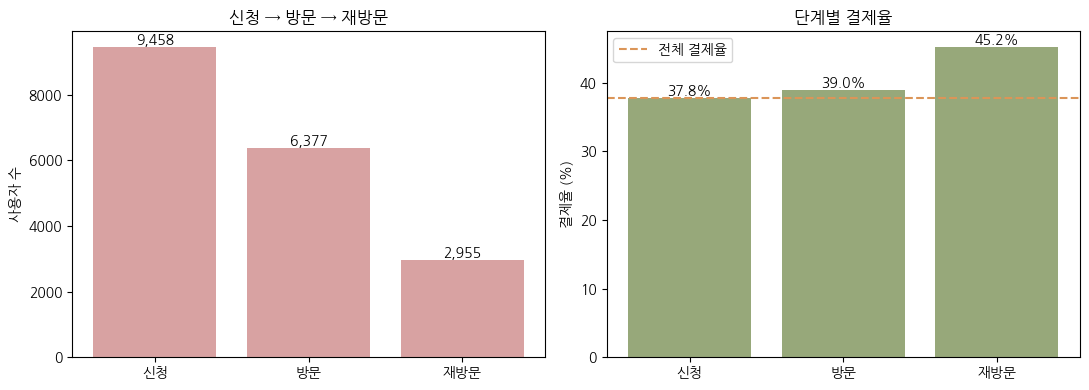

In [32]:
funnel=pd.DataFrame([
    ('신청',len(eda_users),eda_users['is_payment'].sum()),
    ('방문',int(eda_users['visited'].sum()),int(eda_users.loc[eda_users['visited'],'is_payment'].sum())),
    ('재방문',int(eda_users['revisited'].sum()),int(eda_users.loc[eda_users['revisited'],'is_payment'].sum())),
],columns=['단계','인원','결제자'])
funnel['신청자 대비 비율']=funnel['인원']/len(eda_users)
funnel['단계별 결제율']=funnel['결제자']/funnel['인원']
display(funnel)
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].bar(funnel['단계'],funnel['인원'],color=C_SUB)
ax[0].set(title='신청 → 방문 → 재방문',ylabel='사용자 수')
for i,r in funnel.iterrows(): ax[0].text(i,r['인원'],f"{r['인원']:,}",ha='center',va='bottom')
ax[1].bar(funnel['단계'],funnel['단계별 결제율']*100,color=C_MAIN)
ax[1].axhline(eda_users['is_payment'].mean()*100,color=C_ACCENT,ls='--',lw=1.5,label='전체 결제율')
ax[1].set(title='단계별 결제율',ylabel='결제율 (%)')
for i,r in funnel.iterrows(): ax[1].text(i,r['단계별 결제율']*100,f"{r['단계별 결제율']:.1%}",ha='center',va='bottom')
ax[1].legend()
plt.tight_layout();plt.show()

## EDA 2. 방문 일수와 결제 전환

사용자별 **방문 일수**(0~4일)와 **재방문 여부**(방문일수 2일 이상)에 따른 결제율을 비교한다. 같은 날 여러 번 방문해도 방문 일수는 1일로 센다.

,visit_days,n,paid,payment_rate
0,0,3081,1086,0.352483
1,1,3422,1148,0.335476
2,2,1928,826,0.428423
3,3,976,469,0.480533
4,4,51,42,0.823529


,revisited,n,paid,payment_rate
0,False,6503,2234,0.343534
1,True,2955,1337,0.452453


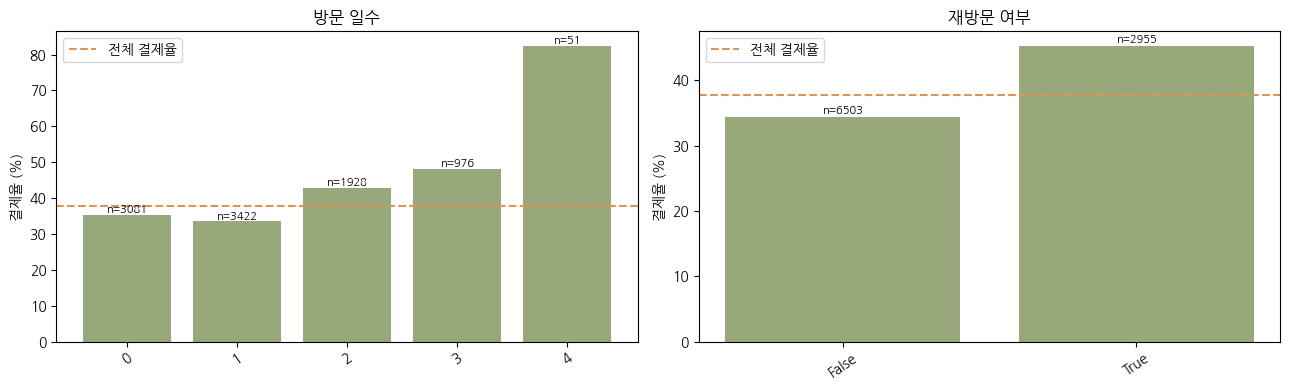

In [33]:
session_count=eda_sessions.groupby('user_uuid').size().rename('visit_sessions')
eda_users=eda_users.merge(session_count,on='user_uuid',how='left')
eda_users['visit_sessions']=eda_users['visit_sessions'].fillna(0).astype(int)

fig,ax=plt.subplots(1,2,figsize=(13,4))
for a,col,title in zip(ax,['visit_days','revisited'],['방문 일수','재방문 여부']):
    tab=conversion_table(eda_users,col)
    display(tab)
    bar_rate(tab,col,title,a)
plt.tight_layout();plt.show()

## EDA 3. 체류시간과 결제 전환

사용자별 **총 체류시간**, **방문일 평균 체류시간**, **최대 하루 체류시간**을 비교한다. 누적 체류시간은 체험 일차별로 나타낸다. 방문일수가 체류시간과 함께 변하므로 구간별 결제율은 연관성으로만 해석한다.

,total_stay_h_group,n,paid,payment_rate
0,0~2,1090,420,0.385321
1,2~4,1161,476,0.409991
2,4~8,1699,661,0.389052
3,8~16,1583,634,0.400505
4,16+,844,294,0.348341


,mean_stay_h_group,n,paid,payment_rate
0,0~2,1348,586,0.434718
1,2~4,1713,751,0.438412
2,4~8,2524,912,0.361331
3,8~16,654,194,0.296636
4,16+,138,42,0.304348


,max_stay_h_group,n,paid,payment_rate
0,0~2,1243,526,0.423170
1,2~4,1458,629,0.431413
2,4~8,2430,911,0.374897
3,8~16,1017,347,0.341200
4,16+,229,72,0.314410


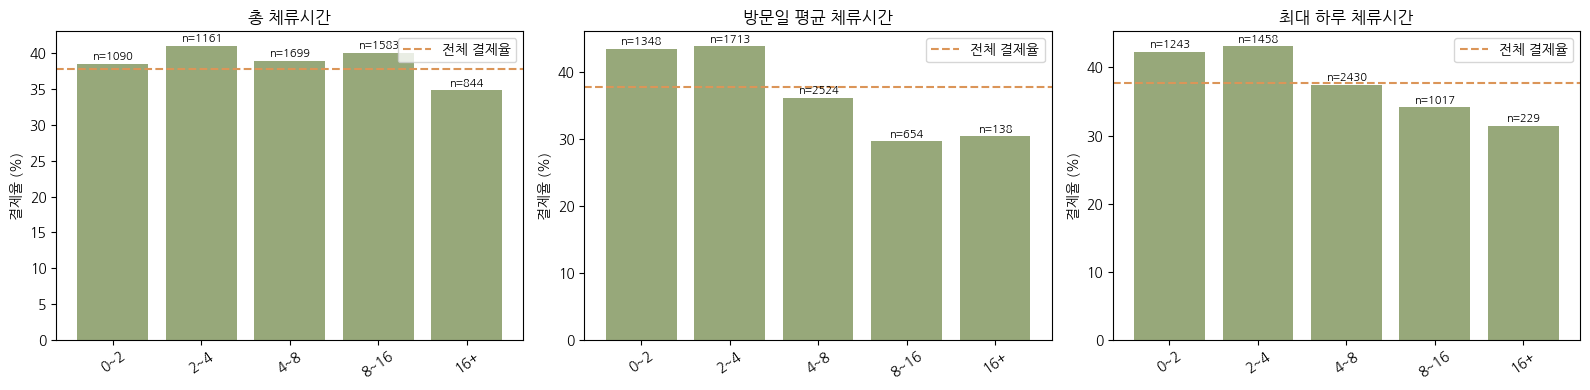

count  median   mean
day_offset is_payment                      
0          0            1010    4.41   5.48
           1             569    3.77   5.02
1          0            2342    5.27   6.26
           1            1551    4.29   5.46
2          0            1682    8.43   9.46
           1            1257    6.61   8.03
3          0            1001   10.10  11.28
           1             998    8.28  10.01

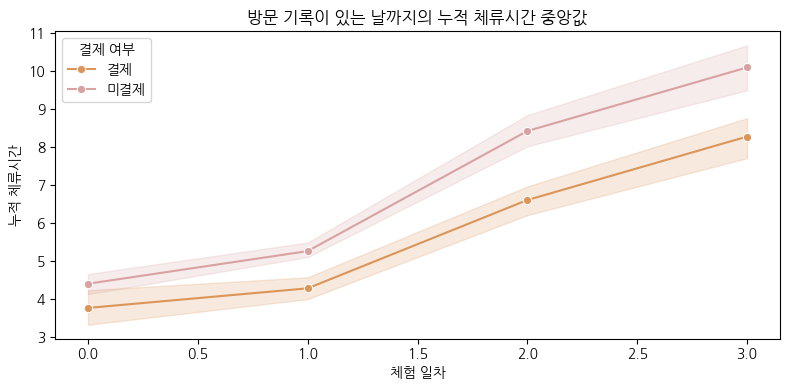

In [34]:
stay_vis=eda_users[eda_users['visited']].copy()
for col in ['total_stay_h','mean_stay_h','max_stay_h']:
    stay_vis[col+'_group']=pd.cut(stay_vis[col],[-0.001,2,4,8,16,np.inf],labels=['0~2','2~4','4~8','8~16','16+'])
fig,ax=plt.subplots(1,3,figsize=(16,4))
for a,col,title in zip(ax,['total_stay_h_group','mean_stay_h_group','max_stay_h_group'],['총 체류시간','방문일 평균 체류시간','최대 하루 체류시간']):
    tab=conversion_table(stay_vis,col);display(tab);bar_rate(tab,col,title,a,min_n=30)
plt.tight_layout();plt.show()

cum=(eda_daily.merge(eda_users[['user_uuid','is_payment']],on='user_uuid',how='inner')
     .groupby(['user_uuid','day_offset','is_payment'],as_index=False)['total_stay_hour'].sum())
cum['누적 체류시간']=cum.groupby('user_uuid')['total_stay_hour'].cumsum()
cum['결제 여부']=cum['is_payment'].map({0:'미결제',1:'결제'})
display(cum.groupby(['day_offset','is_payment'])['누적 체류시간'].agg(['count','median','mean']).round(2))
fig,ax=plt.subplots(figsize=(8,4))
sns.lineplot(data=cum,x='day_offset',y='누적 체류시간',hue='결제 여부',hue_order=['결제','미결제'],
             palette={'결제':C_ACCENT,'미결제':C_SUB},estimator='median',marker='o',ax=ax)
ax.set(title='방문 기록이 있는 날까지의 누적 체류시간 중앙값',xlabel='체험 일차')
plt.tight_layout();plt.show()

## EDA 4. 이용 시간대와 방문 빈도

- **첫 입실 시각**을 2시간 구간으로 나눠 사용자 단위 결제율을 본다.
- **시간당 방문 세션 수**(= 방문 세션 수 ÷ 총 체류시간)로 '짧게 자주 들르는 이용'과 '한 번에 오래 머무는 이용'을 구분한다. 방문 세션 수만 보면 체류시간이 긴 고객에게 유리할 수 있어서 체류시간으로 나눠 비교한다.

,entry_2h,n,paid,payment_rate
0,00~02시,175,61,0.348571
1,02~04시,7,5,0.714286
2,04~06시,8,2,0.250000
3,06~08시,95,32,0.336842
4,08~10시,690,239,0.346377
5,10~12시,981,380,0.387360
6,12~14시,1359,458,0.337013
7,14~16시,1383,511,0.369487
8,16~18시,651,278,0.427035
9,18~20시,611,307,0.502455


,access_group,n,paid,payment_rate
0,≤0.25,3302,1142,0.345851
1,0.25~0.5,1719,753,0.438045
2,0.5~1,695,315,0.453237
3,1~2,456,207,0.453947
4,2+,205,68,0.331707


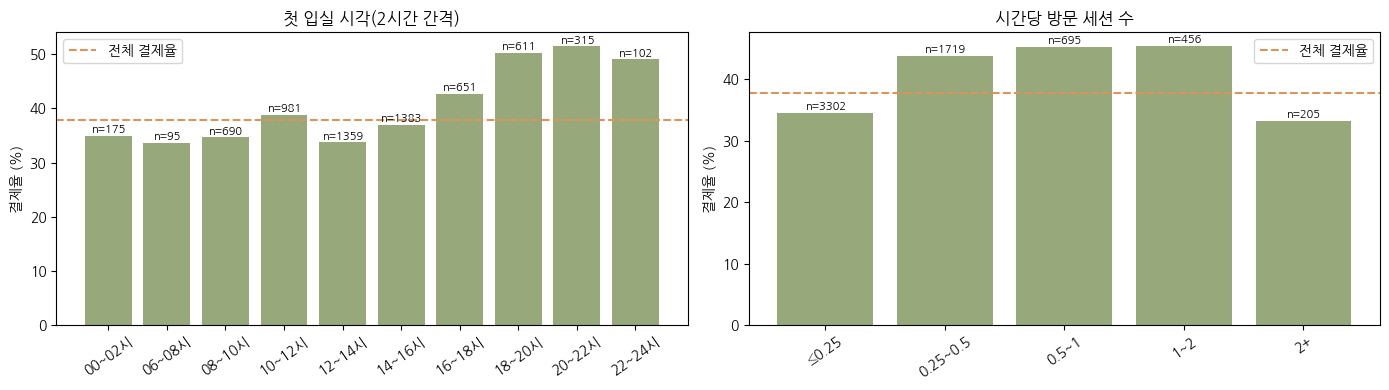

In [35]:
first_entry=(eda_sessions.sort_values(['user_uuid','first_enter_time']).drop_duplicates('user_uuid')
             [['user_uuid','entry_hour']].rename(columns={'entry_hour':'first_entry_hour'}))

time_eda=eda_users[eda_users['visited']].merge(first_entry,on='user_uuid',how='left')
time_eda['entry_2h_start']=(time_eda['first_entry_hour']//2*2).astype('Int64')
time_eda['entry_2h']=time_eda['entry_2h_start'].map(lambda x:f'{x:02d}~{x+2:02d}시' if pd.notna(x) else '시각 없음')
time_eda['access_per_hour']=time_eda['visit_sessions']/time_eda['total_stay_h'].replace(0,np.nan)
time_eda['access_per_hour']=time_eda['access_per_hour'].replace([np.inf,-np.inf],np.nan)
time_eda['access_group']=pd.cut(time_eda['access_per_hour'],[-np.inf,.25,.5,1,2,np.inf],labels=['≤0.25','0.25~0.5','0.5~1','1~2','2+'])
fig,ax=plt.subplots(1,2,figsize=(14,4))
for a,col,title in zip(ax,['entry_2h','access_group'],['첫 입실 시각(2시간 간격)','시간당 방문 세션 수']):
    tab=conversion_table(time_eda,col);display(tab);bar_rate(tab,col,title,a,min_n=30)
plt.tight_layout();plt.show()

## EDA 5. 지점별 차이

가장 오래 이용한 지점을 **주 이용 지점**으로 정의한다. 지점별 표본 수·결제율·면적을 함께 보여주되, 지점 차이를 면적의 인과효과로 해석하지 않는다.

,site_id,n,paid,payment_rate,면적(평)
0,1,789,326,0.413181,50
1,2,1057,376,0.355724,100
2,3,1294,539,0.416538,150
3,4,463,188,0.406048,100
4,5,607,273,0.449753,150
5,6,1261,454,0.360032,150
6,17,446,160,0.358744,50
7,47,326,112,0.343558,50
8,49,134,57,0.425373,50


,area_pyeong,n,paid,payment_rate
0,50,1695,655,0.386431
1,100,1520,564,0.371053
2,150,3162,1266,0.400380


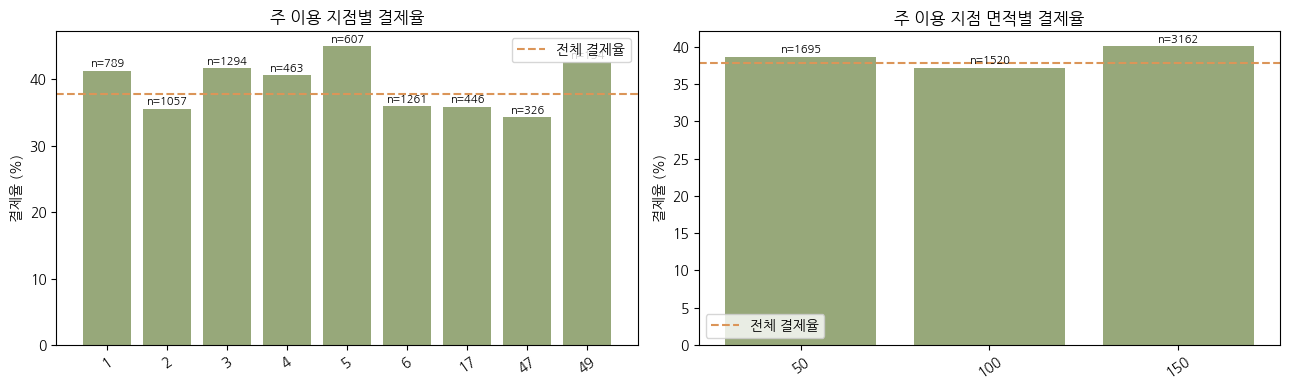

In [36]:
main_site_eda=(eda_sessions.groupby(['user_uuid','site_id'],as_index=False)['stay_hour'].sum()
               .sort_values(['user_uuid','stay_hour','site_id'],ascending=[True,False,True])
               .drop_duplicates('user_uuid')[['user_uuid','site_id']]
               .merge(site,on='site_id',how='left'))
site_eda=eda_users[eda_users['visited']].merge(main_site_eda,on='user_uuid',how='left')
site_tab=conversion_table(site_eda,'site_id').merge(site.rename(columns={'area_pyeong':'면적(평)'}),on='site_id',how='left')
display(site_tab)
fig,ax=plt.subplots(1,2,figsize=(13,4))
bar_rate(site_tab,'site_id','주 이용 지점별 결제율',ax[0],min_n=30)
area_tab=conversion_table(site_eda,'area_pyeong');display(area_tab)
bar_rate(area_tab,'area_pyeong','주 이용 지점 면적별 결제율',ax[1],min_n=30)
plt.tight_layout();plt.show()

---
---
# PART 2. 파생변수 생성 & 변수 추리기

## PART 2 개요

- **입력**: PART 1의 `user_features.csv`, `user_daily_clean.csv`
- **출력**: 방문자 데이터셋의 train/test 파일 + 공통 피처 목록 (PART 3에서 사용)
- **분석 대상**: 체험 0~3일차에 방문 기록이 있는 **방문자**. (미방문자는 행동 데이터가 없어 모델 대상에서 제외하고, 퍼널·EDA에서 다룬다)

### 흐름
```
Train/Test 분할 → 파생변수 생성 → 파생변수 검증 → 방문자 데이터셋 정의
→ ① 의미 중복 그룹 → ② 상관관계 → ③ 타깃 연관성 → 공통 피처 확정 → 저장
```

### 원칙
- **모델 기간은 체험기간 0~3일**이다.
- **분할을 먼저 한다.** 변수 선택(상관, 타깃 연관성)은 **train으로만** 계산한다. test를 보고 고르면 그 자체가 누수다.
- 여기서 정하는 건 **Round 1용 공통 피처**다. 모델별 최적 피처는 PART 3 Round 2에서 고른다.

## 0. 환경 설정

In [37]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import chi2_contingency

from matplotlib import font_manager
# 한글 폰트: 설치된 것 중 첫 번째 사용 (Windows: 맑은 고딕 / Mac: AppleGothic)
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if _font in _installed:
        plt.rcParams['font.family'] = _font
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 60)

DATA_DIR = PREP_DIR        # PART 1 산출물
OUT_DIR  = MODEL_DATA_DIR  # PART 3 입력
RANDOM_STATE = 42
TEST_SIZE    = 0.2
MODEL_MAX_OFFSET = 3        # PART 1과 동일 (모델 피처 기간 day_offset 0~3)
CORR_THRESHOLD   = 0.8      # 이 이상이면 '겹치는 변수'로 판단
LOW_RELEVANCE    = 0.01     # |단변량 AUC - 0.5| 가 이보다 작으면 '타깃 연관성 낮음' 후보

TARGET   = 'is_payment'
ID_COLS  = ['user_uuid', 'trial_date', 'time_restored_user']   # 모델 입력에서 제외할 컬럼 (파일에는 남김)
CAT_COLS = ['main_site_id', 'trial_dow', 'trial_month']   # 숫자처럼 보이지만 '범주'인 변수

## 1. 데이터 로드 & 컬럼명 정리
- 시간대 비율 컬럼(`band_심야` 등)은 모델 라이브러리·그래프에서 한글이 깨질 수 있어 영문으로 바꾼다.
- `user_daily_clean.csv`는 모델 기간(0~3일)만 사용한다.

In [38]:
df = pd.read_csv(DATA_DIR + 'user_features.csv', parse_dates=['trial_date'])
daily = pd.read_csv(DATA_DIR + 'user_daily_clean.csv', parse_dates=['visit_date'])
daily = daily[daily['day_offset'] <= MODEL_MAX_OFFSET]   # 모델 기간(0~3일)만 사용
assert daily['day_offset'].max() <= MODEL_MAX_OFFSET

df = df.rename(columns={
    'band_심야': 'band_dawn',            # 00~05시
    'band_오전': 'band_morning',         # 06~11시
    'band_오후': 'band_afternoon',       # 12~17시
    'band_저녁': 'band_evening',         # 18~23시
})
print(df.shape)
print('결제율:', round(df[TARGET].mean(), 4))

(9458, 40)
결제율: 0.3776


## 2. Train / Test 분할 (가장 먼저)

- **전체 신청자 기준으로 한 번만** 8:2 분할한다 (결제 여부 비율 유지: `stratify`).
- 방문자 데이터셋은 그 안에서 방문자만 뽑는다.

> 전체 신청자 기준으로 나누면, 분석 대상을 바꿔도 **같은 사람이 항상 같은 쪽(train/test)에 들어가** 결과를 일관되게 비교할 수 있다.

In [39]:
train_ids, test_ids = train_test_split(
    df['user_uuid'], test_size=TEST_SIZE, stratify=df[TARGET], random_state=RANDOM_STATE)

df['split'] = np.where(df['user_uuid'].isin(test_ids), 'test', 'train')
print(df.groupby('split')[TARGET].agg(['count', 'mean']).round(4))

       count    mean
split               
test    1892  0.3774
train   7566  0.3776


## 3. 파생변수 생성

기존 피처를 **다른 관점으로 재구성**한 변수들이다. 모두 모델 기간(0~3일차) 정보만 사용하고, `is_payment`는 쓰지 않는다.

| 유형 | 변수 | 정의 | 만든 이유 |
|---|---|---|---|
| 구간 | `stay_level` | 총 체류시간 구간 (0: 미방문, 1: ~2h, 2: 2~5h, 3: 5~9h, 4: 9h~) | 체류시간과 결제의 관계가 직선이 아닐 수 있음 |
| 구간 | `entry_time_group` | 첫 입실 시각 구간 (0: 미방문, 1: 오전, 2: 오후, 3: 저녁·심야) | 출근형/오후형/야간형 이용 구분 |
| 비율 | `visit_ratio` | 방문일수 ÷ 첫 방문 이후 남은 체험일수 | 늦게 온 사람도 '남은 기간 대비' 얼마나 왔는지 공정하게 비교 |
| 비율 | `first_day_share` | 첫날 체류 ÷ 총 체류 | 첫날에 몰아서 쓰고 끝났는지 |
| 비율 | `evening_ratio` | 저녁 입실 방문 ÷ 전체 방문 | 퇴근 후 이용 성향 |
| 비율 | `weekend_ratio` | 주말 방문일 ÷ 방문일 | 주말 이용 성향 |
| 강도 | `avg_stay_per_session` | 총 체류 ÷ 방문 횟수 | 1회 방문 몰입도 |
| 강도 | `entries_per_hour` | 입실 횟수 ÷ 총 체류시간 | 들락날락 빈도 (잠깐 들르는 이용인지) |
| 추세 | `stay_trend` | 마지막 방문일 체류 − 첫 방문일 체류 | 이용이 늘었는지 줄었는지 (1일만 방문 → 0) |
| 시점 | `late_start` | 첫 방문이 신청 다음날 이후 | 바로 안 오고 미룬 사용자 |

In [40]:
visited = df['visit_days'] > 0

# --- 구간 변수 ---
df['stay_level'] = pd.cut(df['total_stay_hour'], bins=[-0.1, 0, 2, 5, 9, np.inf], labels=[0, 1, 2, 3, 4]).astype(int)
df['entry_time_group'] = pd.cut(df['first_entry_hour'], bins=[-1, 5, 11, 17, 23], labels=[3, 1, 2, 3], ordered=False)
df['entry_time_group'] = df['entry_time_group'].astype(float).fillna(0).astype(int)   # 00~05시는 '저녁·심야'(3)로 묶음

# --- 비율 변수 (미방문자는 0) ---
days_available = (MODEL_MAX_OFFSET + 1) - df['first_visit_offset']
df['visit_ratio']     = np.where(visited, df['visit_days'] / days_available, 0)
df['first_day_share'] = np.where(visited, df['first_day_stay_hour'] / df['total_stay_hour'].replace(0, np.nan), 0)
df['evening_ratio']   = np.where(visited, df['evening_entry_count'] / df['visit_sessions'].replace(0, np.nan), 0)
df['weekend_ratio']   = np.where(visited, df['weekend_visit_days'] / df['visit_days'].replace(0, np.nan), 0)

# --- 강도 변수 ---
df['avg_stay_per_session'] = np.where(visited, df['total_stay_hour'] / df['visit_sessions'].replace(0, np.nan), 0)
df['entries_per_hour']     = np.where(df['total_stay_hour'] > 0, df['entry_count'] / df['total_stay_hour'], 0)

# --- 추세 변수: 사용자-날짜 데이터에서 첫 방문일/마지막 방문일 체류 비교 ---
d = daily.sort_values(['user_uuid', 'visit_date'])
trend = (d.groupby('user_uuid')['total_stay_hour'].last() - d.groupby('user_uuid')['total_stay_hour'].first())
df['stay_trend'] = df['user_uuid'].map(trend).fillna(0)

# --- 시점 변수 ---
df['late_start'] = (df['first_visit_offset'] >= 1).astype(int)   # 미방문자는 NaN >= 1 → False → 0

new_cols = ['stay_level', 'entry_time_group', 'visit_ratio', 'first_day_share', 'evening_ratio',
            'weekend_ratio', 'avg_stay_per_session', 'entries_per_hour', 'stay_trend', 'late_start']
df[new_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
stay_level,9458.0,1.841,1.565,0.00,0.0,2.000,3.000,4.000
entry_time_group,9458.0,1.291,1.056,0.00,0.0,1.000,2.000,3.000
visit_ratio,9458.0,0.400,0.356,0.00,0.0,0.333,0.667,1.000
first_day_share,9458.0,0.504,0.428,0.00,0.0,0.478,1.000,1.000
evening_ratio,9458.0,0.111,0.287,0.00,0.0,0.000,0.000,1.000
weekend_ratio,9458.0,0.149,0.322,0.00,0.0,0.000,0.000,1.000
avg_stay_per_session,9458.0,3.240,3.943,0.00,0.0,2.377,5.144,69.223
entries_per_hour,9458.0,0.847,6.722,0.00,0.0,0.371,0.820,400.000
stay_trend,9458.0,-0.141,2.308,-27.26,0.0,0.000,0.000,28.012
late_start,9458.0,0.507,0.500,0.00,0.0,1.000,1.000,1.000


## 4. 파생변수 검증
나눗셈으로 만든 변수는 무한대(inf)·결측이 생기기 쉽다. 범위가 말이 되는지 확인한다.

In [41]:
print('inf 개수:', np.isinf(df[new_cols]).sum().sum())
print('결측 개수:\n', df[new_cols].isna().sum()[lambda s: s > 0])

assert df['visit_ratio'].between(0, 1).all()
assert df['first_day_share'].between(0, 1.0001).all()
assert df['evening_ratio'].between(0, 1).all()
assert df['weekend_ratio'].between(0, 1).all()
print('범위 검증 통과 ✅')

inf 개수: 0
결측 개수:
 Series([], dtype: int64)
범위 검증 통과 ✅


## 5. 방문자 데이터셋 정의

| 대상 | 정의 | 특징 |
|---|---|---|
| 방문자 | 체험 0~3일차 방문 기록 있음 (`visit_days > 0`) | 행동 변수가 모두 채워짐. '방문 후 어떤 행동이 결제로 이어지나'에 집중 |

변수 선택은 이 방문자 데이터 기준으로 한다. (예: 방문자만 보면 `visited`는 항상 1이라 다음 단계에서 자동 제거된다)

In [42]:
feature_cols_all = [c for c in df.columns if c not in ID_COLS + [TARGET, 'split']]

datasets = {
    'visit': df[df['visit_days'] > 0].copy(),   # 방문자만
}
for name, d_ in datasets.items():
    print(f"[{name}] 전체 {len(d_)} / train {(d_['split']=='train').sum()} / test {(d_['split']=='test').sum()} / 결제율 {d_[TARGET].mean():.4f}")
print('후보 피처 수:', len(feature_cols_all))

[visit] 전체 6377 / train 5120 / test 1257 / 결제율 0.3897
후보 피처 수: 46


## 6. 변수 추리기 — 사전 단계: 상수·준상수 제거
값이 거의 하나뿐인 변수는 어떤 모델도 활용할 수 없다. (예: 방문자 데이터의 `visited`)

In [43]:
def drop_constant(train, cols, max_share=0.995):
    # 가장 많은 값의 비중이 max_share 이상이면 제거
    dropped = [c for c in cols if train[c].value_counts(normalize=True, dropna=False).iloc[0] >= max_share]
    return [c for c in cols if c not in dropped], dropped

selection = {}   # 데이터셋별 선택 결과 저장
for name, d_ in datasets.items():
    tr = d_[d_['split'] == 'train']
    kept, dropped = drop_constant(tr, feature_cols_all)
    selection[name] = {'after_constant': kept, 'dropped_constant': dropped}
    print(f'[{name}] 제거:', dropped)

[visit] 제거: ['short_visit_count', 'visited']


## 7. ① 의미 중복 그룹 (사람이 먼저 판단)

상관계수를 보기 전에 **정의상 같은 정보를 담은 변수**를 묶어둔다. 이 표는 이후 상관 결과를 해석하고, 보고서에서 "왜 이 변수를 뺐는가"를 설명하는 근거가 된다.

In [44]:
meaning_groups = {
    '방문 횟수·지속성': ['visit_days', 'visit_sessions', 'revisit', 'visit_span', 'visit_ratio', 'visited', 'n_sites'],
    '방문 일차':        ['visited_d0', 'visited_d1', 'visited_d2', 'visited_d3', 'first_visit_offset', 'last_visit_offset', 'late_start'],
    '체류시간':         ['total_stay_hour', 'max_stay_hour', 'avg_stay_hour_per_day', 'first_day_stay_hour',
                        'avg_stay_per_session', 'stay_level', 'first_day_share', 'stay_trend'],
    '출입 빈도':        ['access_count', 'entry_count', 'exit_count', 'entries_per_day', 'entries_per_hour', 'entry_exit_gap'],
    '이용 시간대':      ['first_entry_hour', 'avg_entry_hour', 'entry_time_group', 'evening_entry_count', 'evening_ratio',
                        'band_dawn', 'band_morning', 'band_afternoon', 'band_evening'],
    '주말 이용':        ['weekend_visit_days', 'weekend_ratio'],
    '지점':             ['main_site_id', 'main_site_area'],
    '신청 시점':        ['trial_dow', 'trial_is_weekend', 'trial_month'],
    '데이터 품질':      ['access_log_missing', 'short_visit_count'],
}
group_of = {c: g for g, cols in meaning_groups.items() for c in cols}
missing = [c for c in feature_cols_all if c not in group_of]
print('그룹 미지정 변수:', missing)
pd.Series(group_of).value_counts()

그룹 미지정 변수: []


,count
이용 시간대,9
체류시간,8
방문 횟수·지속성,7
방문 일차,7
출입 빈도,6
신청 시점,3
주말 이용,2
지점,2
데이터 품질,2


## 8. ③ 타깃 연관성 먼저 계산 (② 상관 제거에서 '누구를 남길지' 기준으로 쓰기 위해)

**단변량 AUC**: 변수 하나만으로 결제자/미결제자를 얼마나 잘 가르는지.
- 0.5 = 전혀 못 가름, 0.5에서 멀수록 연관성 큼
- 0.5보다 작으면 "값이 작을수록 결제" 방향 → 그래서 **`|AUC − 0.5|` 절댓값**으로 영향력을 비교한다.
- 방문자 데이터셋이라 행동 변수에는 결측이 없다. (`fillna(-1)`은 안전장치)

범주형(`main_site_id`, `trial_dow`, `trial_month`)은 크기 비교가 무의미하므로 **카이제곱 검정 p-value**로 따로 본다.

In [45]:
def target_relevance(train, cols):
    rows = []
    y = train[TARGET]
    for c in cols:
        if c in CAT_COLS:
            p = chi2_contingency(pd.crosstab(train[c].fillna(-1), y))[1]
            rows.append({'feature': c, 'type': 'cat', 'auc': np.nan, 'relevance': np.nan, 'chi2_p': p})
        else:
            auc = roc_auc_score(y, train[c].fillna(-1))
            rows.append({'feature': c, 'type': 'num', 'auc': auc, 'relevance': abs(auc - 0.5), 'chi2_p': np.nan})
    out = pd.DataFrame(rows)
    out['group'] = out['feature'].map(group_of)
    out['direction'] = np.where(out['auc'] > 0.5, '+ (클수록 결제↑)', np.where(out['auc'] < 0.5, '- (클수록 결제↓)', ''))
    return out.sort_values('relevance', ascending=False, na_position='last').reset_index(drop=True)

for name, d_ in datasets.items():
    tr = d_[d_['split'] == 'train']
    rel = target_relevance(tr, selection[name]['after_constant'])
    selection[name]['relevance'] = rel
    print(f'\n===== [{name}] 타깃 연관성 상위 15 =====')
    display(rel.head(15).round(4))


===== [visit] 타깃 연관성 상위 15 =====


,feature,type,auc,relevance,chi2_p,group,direction
0,last_visit_offset,num,0.5952,0.0952,NaN,방문 일차,+ (클수록 결제↑)
1,visit_ratio,num,0.5869,0.0869,NaN,방문 횟수·지속성,+ (클수록 결제↑)
2,visit_span,num,0.5705,0.0705,NaN,방문 횟수·지속성,+ (클수록 결제↑)
3,visited_d3,num,0.5687,0.0687,NaN,방문 일차,+ (클수록 결제↑)
4,visit_sessions,num,0.5646,0.0646,NaN,방문 횟수·지속성,+ (클수록 결제↑)
5,visit_days,num,0.5636,0.0636,NaN,방문 횟수·지속성,+ (클수록 결제↑)
6,evening_entry_count,num,0.5632,0.0632,NaN,이용 시간대,+ (클수록 결제↑)
7,avg_stay_per_session,num,0.4387,0.0613,NaN,체류시간,- (클수록 결제↓)
8,avg_stay_hour_per_day,num,0.4394,0.0606,NaN,체류시간,- (클수록 결제↓)
9,first_day_share,num,0.4398,0.0602,NaN,체류시간,- (클수록 결제↓)


In [46]:
# 범주형 변수 검정 결과
for name in datasets:
    rel = selection[name]['relevance']
    print(f'[{name}]'); display(rel[rel['type'] == 'cat'][['feature', 'chi2_p']].round(4))

[visit]


,feature,chi2_p
41,main_site_id,0.0007
42,trial_dow,0.6676
43,trial_month,0.0032


> **읽는 법**: `chi2_p < 0.05`면 범주별 결제율 차이가 통계적으로 유의하다. 단, `trial_month`처럼 **시기**와 관련된 변수는 '그 달의 프로모션/시장 상황'을 학습할 수 있어서, 성능에 도움이 되더라도 해석은 조심해야 한다.

## 9. ② 피처 간 상관관계

- **스피어만 상관**을 쓴다. 체류시간·출입 횟수처럼 치우친(오른쪽 꼬리가 긴) 변수가 많아서, 순위 기반이 더 안정적이다.
- `|r| ≥ 0.8`인 쌍 = 사실상 같은 정보.
- 상관은 **방문자 행**으로만 계산한다. (`visit_days > 0` 조건은 안전장치. 미방문자가 섞이면 모든 행동 변수가 0인 행 때문에 상관이 가짜로 높게 나온다)

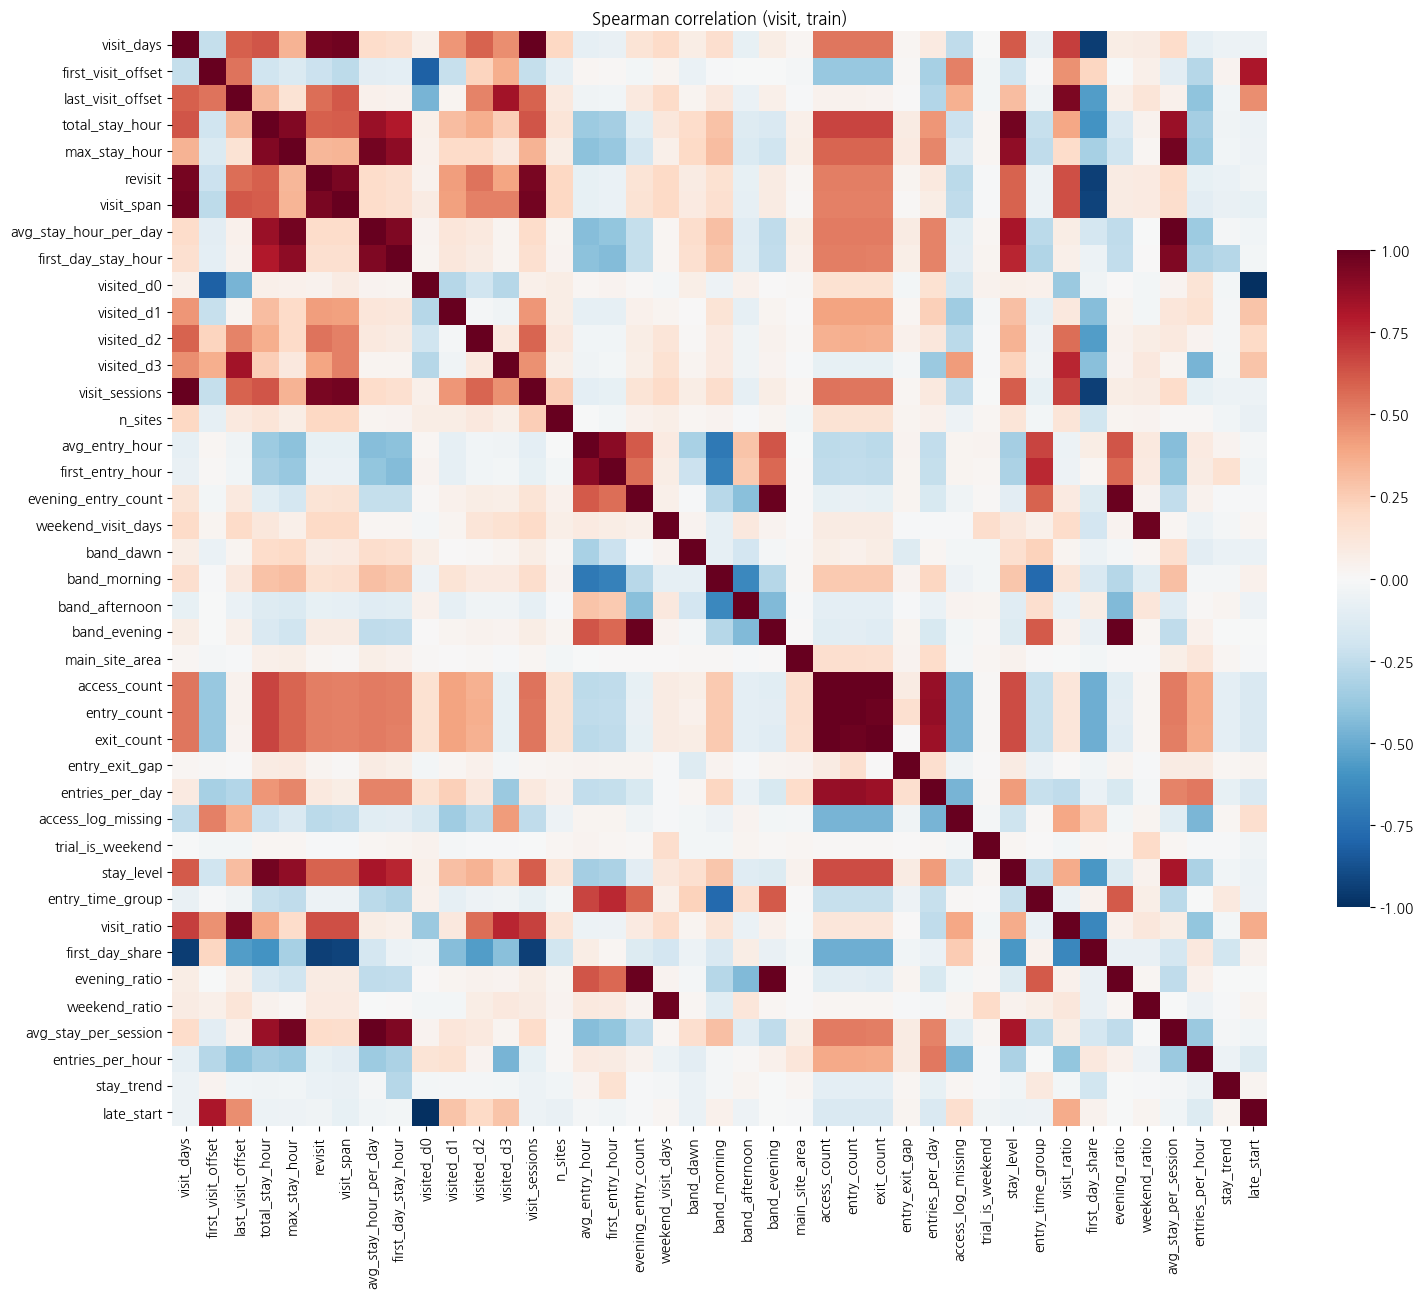

In [47]:
name = 'visit'   # 방문자 데이터셋 기준 히트맵
tr = datasets[name][(datasets[name]['split'] == 'train') & (datasets[name]['visit_days'] > 0)]   # 방문자 행만
num_cols = [c for c in selection[name]['after_constant'] if c not in CAT_COLS]
corr = tr[num_cols].corr(method='spearman')

plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.6})
plt.title(f'Spearman correlation ({name}, train)')
plt.tight_layout(); plt.show()

In [48]:
def corr_matrix(train, cols):
    # 방문자 행만으로 스피어만 상관 계산 (값이 하나뿐이라 NaN이 나오면 0으로)
    vis = train[train['visit_days'] > 0]
    return vis[cols].corr(method='spearman').abs().fillna(0)

def high_corr_pairs(train, cols, th=CORR_THRESHOLD):
    c = corr_matrix(train, cols)
    upper = c.where(np.triu(np.ones(c.shape, dtype=bool), k=1))
    pairs = upper.stack().reset_index()
    pairs.columns = ['var1', 'var2', 'abs_r']
    pairs = pairs[pairs['abs_r'] >= th].sort_values('abs_r', ascending=False)
    pairs['same_group'] = pairs['var1'].map(group_of) == pairs['var2'].map(group_of)
    return pairs

for name, d_ in datasets.items():
    tr = d_[d_['split'] == 'train']
    num_cols = [c for c in selection[name]['after_constant'] if c not in CAT_COLS]
    pairs = high_corr_pairs(tr, num_cols)
    selection[name]['corr_pairs'] = pairs
    print(f'\n===== [{name}] |r| ≥ {CORR_THRESHOLD} 쌍: {len(pairs)}개 =====')
    display(pairs.head(20).round(3))


===== [visit] |r| ≥ 0.8 쌍: 40개 =====


,var1,var2,abs_r,same_group
354,visited_d0,late_start,1.000,True
661,band_evening,evening_ratio,1.000,True
288,avg_stay_hour_per_day,avg_stay_per_session,0.998,True
684,access_count,entry_count,0.996,True
685,access_count,exit_count,0.995,True
12,visit_days,visit_sessions,0.994,True
561,evening_entry_count,evening_ratio,0.991,True
548,evening_entry_count,band_evening,0.991,True
700,entry_count,exit_count,0.983,True
584,weekend_visit_days,weekend_ratio,0.978,True


> `same_group = True`가 대부분이면 7번에서 사람이 판단한 의미 중복과 숫자가 일치한다는 뜻이다. `False`인 쌍은 '다른 개념인데 데이터상 같이 움직이는' 변수라 해석할 때 한 번 더 본다.

## 10. 공통 피처 확정 (Round 1용)

**규칙**
1. 수치형 변수를 **타깃 연관성(`|AUC−0.5|`) 높은 순**으로 줄 세운다.
2. 위에서부터 하나씩 넣되, 이미 넣은 변수와 `|r| ≥ 0.8`이면 **빼고 제거 목록에 기록**한다. → 겹치는 변수 중 결제와 더 관련 있는 쪽이 살아남는다.
3. 범주형 3개는 상관 계산 대상이 아니므로 그대로 포함한다.
4. `|AUC−0.5| < 0.01`인 변수는 **'제거 후보'로 표시만** 한다. 단변량으로 약해도 다른 변수와 조합되면 쓸모 있을 수 있어서, 실제 제거는 PART 3 Round 2에서 **모델별로** 검증한다.

In [49]:
def select_common(train, rel, cols, th=CORR_THRESHOLD):
    num_rank = rel[(rel['type'] == 'num') & rel['feature'].isin(cols)]['feature'].tolist()
    c = corr_matrix(train, num_rank)
    kept, removed = [], []
    for f in num_rank:
        hit = [k for k in kept if c.loc[f, k] >= th]
        if hit:
            removed.append({'removed': f, 'kept_instead': hit[0], 'abs_r': round(c.loc[f, hit[0]], 3)})
        else:
            kept.append(f)
    cats = [c_ for c_ in CAT_COLS if c_ in cols]
    low = rel[(rel['feature'].isin(kept)) & (rel['relevance'] < LOW_RELEVANCE)]['feature'].tolist()
    return kept + cats, pd.DataFrame(removed), low

for name, d_ in datasets.items():
    tr = d_[d_['split'] == 'train']
    common, removed, low = select_common(tr, selection[name]['relevance'], selection[name]['after_constant'])
    selection[name].update({'common': common, 'removed_corr': removed, 'low_relevance': low})
    print(f'\n===== [{name}] 공통 피처 {len(common)}개 =====')
    print(common)
    print('\n상관으로 제거된 변수:')
    display(removed)
    print('타깃 연관성 낮음(제거 후보, Round 2에서 검증):', low)


===== [visit] 공통 피처 24개 =====
['last_visit_offset', 'visit_span', 'evening_entry_count', 'avg_stay_per_session', 'entries_per_day', 'first_entry_hour', 'entry_time_group', 'band_afternoon', 'visited_d2', 'first_visit_offset', 'entries_per_hour', 'band_morning', 'access_log_missing', 'n_sites', 'main_site_area', 'visited_d1', 'trial_is_weekend', 'weekend_ratio', 'entry_exit_gap', 'band_dawn', 'stay_trend', 'main_site_id', 'trial_dow', 'trial_month']

상관으로 제거된 변수:


,removed,kept_instead,abs_r
0,visit_ratio,last_visit_offset,0.940
1,visited_d3,last_visit_offset,0.837
2,visit_sessions,visit_span,0.966
3,visit_days,visit_span,0.971
4,avg_stay_hour_per_day,avg_stay_per_session,0.998
5,first_day_share,visit_span,0.923
6,evening_ratio,evening_entry_count,0.991
7,band_evening,evening_entry_count,0.991
8,first_day_stay_hour,avg_stay_per_session,0.931
9,revisit,visit_span,0.952


타깃 연관성 낮음(제거 후보, Round 2에서 검증): ['n_sites', 'main_site_area', 'visited_d1', 'trial_is_weekend', 'weekend_ratio', 'entry_exit_gap', 'band_dawn', 'stay_trend']


## 11. 결과 요약 & 저장

In [50]:
summary = pd.DataFrame({
    name: {
        '사용자 수(train)': (datasets[name]['split'] == 'train').sum(),
        '후보 피처': len(feature_cols_all),
        '상수 제거 후': len(s['after_constant']),
        '상관 제거 후 = 공통 피처': len(s['common']),
        '제거 후보(연관성 낮음)': len(s['low_relevance']),
    } for name, s in selection.items()
})
display(summary)

for name, d_ in datasets.items():
    keep_cols = ID_COLS + feature_cols_all + [TARGET]
    d_[d_['split'] == 'train'][keep_cols].to_csv(OUT_DIR + f'train_{name}.csv', index=False, encoding='utf-8-sig')
    d_[d_['split'] == 'test'][keep_cols].to_csv(OUT_DIR + f'test_{name}.csv', index=False, encoding='utf-8-sig')

feature_config = {
    name: {'all_features': s['after_constant'], 'common': s['common'],
           'low_relevance': s['low_relevance'], 'cat_cols': [c for c in CAT_COLS if c in s['common']]}
    for name, s in selection.items()
}
with open(OUT_DIR + 'feature_config.json', 'w', encoding='utf-8') as f:
    json.dump(feature_config, f, ensure_ascii=False, indent=2)
print('저장 완료: train_visit.csv / test_visit.csv / feature_config.json')

,visit
사용자 수(train),5120
후보 피처,46
상수 제거 후,44
상관 제거 후 = 공통 피처,24
제거 후보(연관성 낮음),8


저장 완료: train_visit.csv / test_visit.csv / feature_config.json


### 📌 PART 3으로 넘기는 것
- `feature_config.json`
  - `common`: Round 1 공통 피처
  - `all_features`: Round 2 모델별 선택의 출발점 (상관 제거 전 전체)
  - `low_relevance`: 제거 후보
- **test 파일은 PART 3의 최종 평가 전까지 사용하지 않는다.**

---
# PART 3. 결제 전환 예측 모델링 (방문자)

- **입력**: PART 2의 `train_visit.csv`, `test_visit.csv`, `feature_config.json`
- **대상**: 체험 0~3일차 방문자
- **주 지표**: 5-fold CV ROC-AUC / 개선 인정 기준 **+0.005** / test 평가는 마지막에 **1회**

```
Baseline → Round 1(공통 피처) → Round 2(피처 선택·튜닝·가중치) → Round 3(앙상블·최종 선정)
→ Threshold → Test 평가 → 해석(SHAP·Permutation) → 결과 요약
```

## 0. 환경 설정

In [51]:
DATASET  = 'visit'
USE_LGBM = True          # Windows에서 LightGBM import 시 커널이 죽으면 False
N_ITER   = 10            # 튜닝 시 파라미터 조합 시도 횟수

DATA_DIR = MODEL_DATA_DIR   # PART 2 산출물
OUT_DIR  = MODEL_OUT_DIR    # 결과 저장
RANDOM_STATE = 42
N_FOLDS  = 5
MIN_GAIN = 0.005            # CV AUC 개선 인정 기준
CV_TEST_GAP_WARN = 0.02     # CV-test AUC 차이 경고 기준
MAX_FLAG_SHARE = 0.5        # threshold 선택 시 '결제 예상' 비율 상한
TARGET   = 'is_payment'

# 시각화 색상 (EDA와 동일)
C_MAIN, C_ACCENT, C_SUB = '#97A87A', '#DB9558', '#D8A2A2'

In [52]:
import json, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

from sklearn.base import clone, BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,
                             accuracy_score, precision_recall_curve, confusion_matrix)
from scipy.stats import loguniform
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
if USE_LGBM:
    from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if _font in _installed:
        plt.rcParams['font.family'] = _font
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 40)

# ---- 데이터 로드 ----
train = pd.read_csv(DATA_DIR + f'train_{DATASET}.csv')
test  = pd.read_csv(DATA_DIR + f'test_{DATASET}.csv')    # ⚠️ 5번(최종 평가) 전까지 사용 금지
with open(DATA_DIR + 'feature_config.json', encoding='utf-8') as f:
    cfg = json.load(f)[DATASET]

CAT_COLS = cfg['cat_cols']
COMMON   = cfg['common']
ALL_FEAT = cfg['all_features']

for d in (train, test):
    d[CAT_COLS] = d[CAT_COLS].fillna(-1).astype(int)

y_train, y_test = train[TARGET], test[TARGET]
print(f'train {train.shape} / test {test.shape} / 결제율 train {y_train.mean():.4f}')
print(f'공통 피처 {len(COMMON)}개 / 전체 후보 {len(ALL_FEAT)}개')

train (5120, 50) / test (1257, 50) / 결제율 train 0.3885
공통 피처 24개 / 전체 후보 44개


## 1. 평가 함수
모든 실험은 **같은 5-fold**로 평가하고, fold별 AUC 평균·표준편차와 OOF 예측값을 기록한다. P/R/F1은 threshold 0.5 기준 참고값이다.

In [53]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
FOLDS = list(skf.split(train, y_train))

def metrics_at(y, prob, th=0.5):
    pred = (prob >= th).astype(int)
    return {'precision': precision_score(y, pred, zero_division=0),
            'recall': recall_score(y, pred, zero_division=0),
            'f1': f1_score(y, pred, zero_division=0),
            'accuracy': accuracy_score(y, pred)}

def fold_aucs(y, oof):
    return [roc_auc_score(y.iloc[va], oof[va]) for _, va in FOLDS]

def cv_evaluate(model, X, y):
    oof = np.zeros(len(X))
    for tr, va in FOLDS:
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
    aucs = fold_aucs(y, oof)
    return {'auc': np.mean(aucs), 'auc_std': np.std(aucs), **metrics_at(y, oof)}, oof

exp_log = []
def log_exp(stage, name, n_feat, res, note=''):
    exp_log.append({'dataset': DATASET, 'stage': stage, 'model': name, 'n_feat': n_feat,
                    **{k: round(v, 4) for k, v in res.items()}, 'note': note})

## 2. Baseline
- **B0**: Dummy (AUC 0.5)
- **B1**: 로지스틱 회귀 + `visit_days` 1개 → 모든 모델이 넘어야 할 기준선

In [54]:
res_b0, _ = cv_evaluate(DummyClassifier(strategy='prior'), train[['visit_days']], y_train)
log_exp('Baseline', 'B0_Dummy', 0, res_b0)

res_b1, _ = cv_evaluate(LogisticRegression(max_iter=1000), train[['visit_days']], y_train)
log_exp('Baseline', 'B1_LR_visit_days', 1, res_b1)
B1_AUC = res_b1['auc']

display(pd.DataFrame(exp_log).round(4))

,dataset,stage,model,n_feat,auc,auc_std,precision,recall,f1,accuracy,note
0,visit,Baseline,B0_Dummy,0,0.5000,0.000,0.0000,0.0000,0.000,0.6115,
1,visit,Baseline,B1_LR_visit_days,1,0.5637,0.014,0.4976,0.0513,0.093,0.6113,


## 3. 모델 정의
| 모델 | 결측 | 범주형 | 스케일링 |
|---|---|---|---|
| 로지스틱 회귀 | -1 대체 | 원-핫 | 표준화 |
| 랜덤 포레스트 | -1 대체 | 숫자 그대로 | - |
| XGBoost / LightGBM | 그대로 | 숫자 그대로 | - |
| CatBoost | 그대로 | 범주형 직접 처리 | - |

In [55]:
class CatBoostWrapper(ClassifierMixin, BaseEstimator):
    # scikit-learn clone()과의 충돌을 피하기 위한 래퍼 (동작은 CatBoost와 동일)
    def __init__(self, cat_features=(), iterations=300, learning_rate=0.05, depth=6,
                 l2_leaf_reg=3, auto_class_weights=None, random_seed=42):
        self.cat_features = cat_features
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.auto_class_weights = auto_class_weights
        self.random_seed = random_seed

    def fit(self, X, y):
        self.model_ = CatBoostClassifier(iterations=self.iterations, learning_rate=self.learning_rate,
                                         depth=self.depth, l2_leaf_reg=self.l2_leaf_reg,
                                         auto_class_weights=self.auto_class_weights,
                                         random_seed=self.random_seed, verbose=0)
        self.model_.fit(X, y, cat_features=list(self.cat_features))
        self.classes_ = self.model_.classes_
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def predict(self, X):
        return self.model_.predict(X)

    @property
    def feature_importances_(self):
        return self.model_.get_feature_importance()

def make_model(name, feats, balanced=False):
    cats = [c for c in feats if c in CAT_COLS]
    nums = [c for c in feats if c not in CAT_COLS]
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    if name == 'LR':
        prep = ColumnTransformer([
            ('num', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value=-1)),
                              ('sc', StandardScaler())]), nums),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cats)])
        est = LogisticRegression(max_iter=3000, class_weight='balanced' if balanced else None)
        return Pipeline([('prep', prep), ('model', est)])
    if name == 'RF':
        est = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE,
                                     class_weight='balanced' if balanced else None)
        return Pipeline([('prep', SimpleImputer(strategy='constant', fill_value=-1)), ('model', est)])
    if name == 'XGB':
        est = XGBClassifier(n_estimators=300, learning_rate=0.05, eval_metric='logloss',
                            random_state=RANDOM_STATE, scale_pos_weight=pos_weight if balanced else 1)
    elif name == 'LGBM':
        est = LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=RANDOM_STATE,
                             importance_type='gain', class_weight='balanced' if balanced else None)
    elif name == 'CAT':
        est = CatBoostWrapper(cat_features=tuple(cats), random_seed=RANDOM_STATE,
                              auto_class_weights='Balanced' if balanced else None)
    return Pipeline([('model', est)])

MODELS = ['LR', 'RF', 'XGB', 'CAT'] + (['LGBM'] if USE_LGBM else [])
MODEL_NAMES = {'LR': '로지스틱 회귀', 'RF': '랜덤 포레스트', 'XGB': 'XGBoost', 'CAT': 'CatBoost', 'LGBM': 'LightGBM'}

## Round 1. 공통 피처로 모델 비교


In [56]:
r1 = {}
for name in MODELS:
    res, _ = cv_evaluate(make_model(name, COMMON), train[COMMON], y_train)
    r1[name] = res
    log_exp('R1_common', name, len(COMMON), res)

r1_table = pd.DataFrame(r1).T
r1_table['vs_B1'] = r1_table['auc'] - B1_AUC
r1_table.rename(index=MODEL_NAMES).round(4).sort_values('auc', ascending=False)

,auc,auc_std,precision,recall,f1,accuracy,vs_B1
CatBoost,0.6417,0.0103,0.6057,0.2896,0.3918,0.6508,0.0780
로지스틱 회귀,0.6318,0.0124,0.5814,0.2765,0.3748,0.6416,0.0681
랜덤 포레스트,0.6301,0.0087,0.5548,0.3539,0.4322,0.6387,0.0663
LightGBM,0.6253,0.0060,0.5462,0.3746,0.4444,0.6361,0.0615
XGBoost,0.6214,0.0071,0.5495,0.3519,0.4291,0.6361,0.0577


## Round 2-1. 모델별 피처 선택
중요도 상위 k개로 CV AUC 비교 → 최고 AUC와 0.002 이내면 **적은 피처** 선택. (LR은 공통 피처, 트리 모델은 전체 후보에서 출발)
> ⚠️ 중요도를 train 전체로 계산하므로 CV AUC가 다소 낙관적이다.

In [57]:
def get_importance(name, model, feats):
    m = model.named_steps['model']
    if name == 'LR':
        names = model.named_steps['prep'].get_feature_names_out()
        coef = np.abs(m.coef_[0])
        imp = {}
        for n, c in zip(names, coef):
            base = n.replace('num__', '')
            for cat in CAT_COLS:
                if n.startswith(f'cat__{cat}_'):
                    base = cat
            imp[base] = imp.get(base, 0) + c        # 원-핫 컬럼은 원래 변수로 합산
        return pd.Series(imp).reindex(feats).fillna(0)
    return pd.Series(m.feature_importances_, index=feats)

best_feats, r2_select = {}, {}
for name in MODELS:
    start = COMMON if name == 'LR' else ALL_FEAT
    full = make_model(name, start).fit(train[start], y_train)
    imp = get_importance(name, full, start).abs().sort_values(ascending=False)

    ks = sorted({k for k in [len(start), 30, 25, 20, 15, 10, 7, 5] if k <= len(start)}, reverse=True)
    rows = []
    for k in ks:
        feats = imp.index[:k].tolist()
        res, _ = cv_evaluate(make_model(name, feats), train[feats], y_train)
        rows.append({'k': k, 'auc': res['auc'], 'auc_std': res['auc_std'], 'feats': feats})
    tbl = pd.DataFrame(rows)
    chosen = tbl[tbl['auc'] >= tbl['auc'].max() - 0.002].sort_values('k').iloc[0]
    best_feats[name] = chosen['feats']
    r2_select[name] = tbl
    print(f"{MODEL_NAMES[name]:8s} 선택 k={chosen['k']:2d}  AUC {chosen['auc']:.4f}   (k별: " +
          ', '.join(f"{r.k}:{r.auc:.4f}" for r in tbl.itertuples()) + ')')

로지스틱 회귀  선택 k=10  AUC 0.6332   (k별: 24:0.6318, 20:0.6329, 15:0.6345, 10:0.6332, 7:0.6313, 5:0.6055)
랜덤 포레스트  선택 k=25  AUC 0.6215   (k별: 44:0.6209, 30:0.6226, 25:0.6215, 20:0.6092, 15:0.6031, 10:0.5958, 7:0.5728, 5:0.5346)
XGBoost  선택 k= 5  AUC 0.6205   (k별: 44:0.6170, 30:0.6187, 25:0.6169, 20:0.6053, 15:0.6092, 10:0.6078, 7:0.6071, 5:0.6205)
CatBoost 선택 k=15  AUC 0.6393   (k별: 44:0.6401, 30:0.6345, 25:0.6389, 20:0.6392, 15:0.6393, 10:0.6263, 7:0.6180, 5:0.5921)
LightGBM 선택 k=25  AUC 0.6223   (k별: 44:0.6164, 30:0.6207, 25:0.6223, 20:0.6186, 15:0.6145, 10:0.5950, 7:0.5920, 5:0.5757)


In [58]:
# 모델별 선택 피처 (O = 사용) — 여러 모델이 공통으로 고른 피처 = 핵심 행동 변수
used = sorted({f for fs in best_feats.values() for f in fs})
feat_matrix = pd.DataFrame({MODEL_NAMES[m]: ['O' if f in best_feats[m] else '' for f in used] for m in MODELS}, index=used)
feat_matrix['사용 모델 수'] = (feat_matrix == 'O').sum(axis=1)
feat_matrix.sort_values('사용 모델 수', ascending=False)

,로지스틱 회귀,랜덤 포레스트,XGBoost,CatBoost,LightGBM,사용 모델 수
last_visit_offset,O,O,O,O,O,5
trial_dow,O,O,,O,O,4
trial_month,O,O,,O,O,4
main_site_id,O,O,,O,O,4
avg_stay_per_session,O,O,,O,O,4
visit_span,O,O,,O,O,4
first_day_share,,O,,O,O,3
stay_trend,,O,,O,O,3
evening_entry_count,O,,O,,O,3
avg_stay_hour_per_day,,O,,O,O,3


## Round 2-2. 하이퍼파라미터 튜닝 (RandomizedSearchCV)
> ⚠️ 튜닝도 평가와 **같은 5-fold**로 하므로 R2 CV AUC는 다소 낙관적일 수 있다. 최종 성능은 5번 test AUC로 판단한다.

In [59]:
PARAM_SPACE = {
    'LR':  {'model__C': loguniform(1e-3, 10)},
    'RF':  {'model__max_depth': [4, 6, 8, 10, None], 'model__min_samples_leaf': [5, 10, 20, 50],
            'model__max_features': ['sqrt', 0.3, 0.5]},
    'XGB': {'model__max_depth': [2, 3, 4, 5], 'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
            'model__n_estimators': [100, 200, 400], 'model__subsample': [0.7, 0.85, 1.0],
            'model__colsample_bytree': [0.6, 0.8, 1.0], 'model__min_child_weight': [1, 5, 10, 20]},
    'LGBM': {'model__num_leaves': [7, 15, 31], 'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
             'model__n_estimators': [100, 200, 400], 'model__min_child_samples': [20, 50, 100],
             'model__subsample': [0.7, 0.85, 1.0], 'model__subsample_freq': [1],
             'model__colsample_bytree': [0.6, 0.8, 1.0]},
    'CAT': {'model__depth': [3, 4, 5, 6], 'model__learning_rate': [0.02, 0.05, 0.1],
            'model__iterations': [200, 400], 'model__l2_leaf_reg': [1, 3, 10]},
}

best_params, r2_tuned, oof_tuned = {}, {}, {}
for name in MODELS:
    feats = best_feats[name]
    search = RandomizedSearchCV(make_model(name, feats), PARAM_SPACE[name], n_iter=N_ITER,
                                scoring='roc_auc', cv=FOLDS, random_state=RANDOM_STATE, n_jobs=1)
    search.fit(train[feats], y_train)
    best_params[name] = search.best_params_
    res, oof = cv_evaluate(search.best_estimator_, train[feats], y_train)
    r2_tuned[name], oof_tuned[name] = res, oof
    log_exp('R2_tuned', name, len(feats), res, str(search.best_params_))

r2_compare = pd.DataFrame({
    'R1_공통피처': {m: r1[m]['auc'] for m in MODELS},
    'R2_피처선택+튜닝': {m: r2_tuned[m]['auc'] for m in MODELS},
    'R2_std': {m: r2_tuned[m]['auc_std'] for m in MODELS},
    '피처 수': {m: len(best_feats[m]) for m in MODELS},
})
r2_compare['변화'] = r2_compare['R2_피처선택+튜닝'] - r2_compare['R1_공통피처']
r2_compare['개선 인정'] = np.where(r2_compare['변화'] >= MIN_GAIN, 'O', '-')
r2_compare.rename(index=MODEL_NAMES).round(4).sort_values('R2_피처선택+튜닝', ascending=False)

,R1_공통피처,R2_피처선택+튜닝,R2_std,피처 수,변화,개선 인정
CatBoost,0.6417,0.6414,0.0127,15,-0.0003,-
랜덤 포레스트,0.6301,0.6406,0.0133,25,0.0106,O
LightGBM,0.6253,0.6388,0.0163,25,0.0135,O
로지스틱 회귀,0.6318,0.6354,0.0118,10,0.0036,-
XGBoost,0.6214,0.6219,0.0111,5,0.0005,-


## Round 2-3. 클래스 가중치
AUC가 +0.005 이상 오를 때만 채택한다. (Recall 조정은 4번 Threshold에서 처리)

In [60]:
use_balanced = {}
rows = []
for name in MODELS:
    feats = best_feats[name]
    m = make_model(name, feats, balanced=True).set_params(**best_params[name])
    res, oof = cv_evaluate(m, train[feats], y_train)
    gain = res['auc'] - r2_tuned[name]['auc']
    use_balanced[name] = gain >= MIN_GAIN
    rows.append({'model': MODEL_NAMES[name], 'AUC 변화': gain,
                 'Recall(0.5) 가중치 X': r2_tuned[name]['recall'],
                 'Recall(0.5) 가중치 O': res['recall'], '채택': 'O' if use_balanced[name] else '-'})
    if use_balanced[name]:
        r2_tuned[name], oof_tuned[name] = res, oof
    log_exp('R2_balanced', name, len(feats), res, f'채택={use_balanced[name]}')
pd.DataFrame(rows).round(4)

,model,AUC 변화,Recall(0.5) 가중치 X,Recall(0.5) 가중치 O,채택
0,로지스틱 회귀,-0.0002,0.2388,0.5767,-
1,랜덤 포레스트,0.0011,0.2418,0.5163,-
2,XGBoost,-0.0001,0.1931,0.5425,-
3,CatBoost,-0.0006,0.2278,0.5229,-
4,LightGBM,-0.0021,0.2393,0.5425,-


## Round 3. 앙상블 & 최종 모델 선정
- 상위 3개 모델로 Soft Voting / Stacking (OOF 재사용)
- **선정 규칙**: 앙상블이 최고 단일 모델보다 +0.005 이상 높을 때만 앙상블 채택 → 아니면 단일 모델 중 **1위와 차이 0.005 미만(동점 그룹)에서 표준편차가 가장 작은 모델**

In [61]:
top3 = sorted(MODELS, key=lambda m: r2_tuned[m]['auc'], reverse=True)[:3]
print('상위 3개:', [MODEL_NAMES[m] for m in top3], '/ OOF 예측 상관(스피어만):')
display(pd.DataFrame({MODEL_NAMES[m]: oof_tuned[m] for m in top3}).corr(method='spearman').round(3))

def eval_oof(oof):
    aucs = fold_aucs(y_train, oof)
    return {'auc': np.mean(aucs), 'auc_std': np.std(aucs), **metrics_at(y_train, oof)}

candidates = {m: ([m], 'single', r2_tuned[m], oof_tuned[m]) for m in MODELS}

for k in [2, 3]:
    for combo in itertools.combinations(top3, k):
        oof = np.mean([oof_tuned[m] for m in combo], axis=0)
        res = eval_oof(oof)
        key = 'Vote(' + '+'.join(combo) + ')'
        candidates[key] = (list(combo), 'vote', res, oof)
        log_exp('R3_ensemble', key, np.nan, res)

meta_X = np.column_stack([oof_tuned[m] for m in top3])
oof_stack = np.zeros(len(train))
for tr, va in FOLDS:
    meta = LogisticRegression().fit(meta_X[tr], y_train.iloc[tr])
    oof_stack[va] = meta.predict_proba(meta_X[va])[:, 1]
key = 'Stack(' + '+'.join(top3) + ')'
candidates[key] = (top3, 'stack', eval_oof(oof_stack), oof_stack)
log_exp('R3_ensemble', key, np.nan, candidates[key][2])

cand_table = pd.DataFrame({k: v[2] for k, v in candidates.items()}).T[['auc', 'auc_std', 'precision', 'recall', 'f1']]
cand_table.round(4).sort_values('auc', ascending=False)

상위 3개: ['CatBoost', '랜덤 포레스트', 'LightGBM'] / OOF 예측 상관(스피어만):


,CatBoost,랜덤 포레스트,LightGBM
CatBoost,1.000,0.946,0.907
랜덤 포레스트,0.946,1.000,0.942
LightGBM,0.907,0.942,1.000


,auc,auc_std,precision,recall,f1
Vote(CAT+LGBM),0.6443,0.0143,0.6373,0.2438,0.3527
Vote(CAT+RF+LGBM),0.6438,0.0138,0.6346,0.2418,0.3502
Stack(CAT+RF+LGBM),0.6431,0.0132,0.6133,0.2735,0.3783
Vote(CAT+RF),0.6427,0.0126,0.6385,0.2353,0.3439
Vote(RF+LGBM),0.6422,0.0146,0.6295,0.2443,0.3520
CAT,0.6414,0.0127,0.6283,0.2278,0.3343
RF,0.6406,0.0133,0.6239,0.2418,0.3486
LGBM,0.6388,0.0163,0.6048,0.2393,0.3429
LR,0.6354,0.0118,0.5871,0.2388,0.3395
XGB,0.6219,0.0111,0.6316,0.1931,0.2957


In [62]:
singles = {k: v for k, v in candidates.items() if v[1] == 'single'}
top_single = max(singles, key=lambda k: singles[k][2]['auc'])
BEST_SINGLE_AUC = singles[top_single][2]['auc']
close = [k for k in singles if BEST_SINGLE_AUC - singles[k][2]['auc'] < MIN_GAIN]   # 동점 그룹
best_single = min(close, key=lambda k: singles[k][2]['auc_std'])

best_overall = max(candidates, key=lambda k: candidates[k][2]['auc'])
if candidates[best_overall][1] != 'single' and candidates[best_overall][2]['auc'] - BEST_SINGLE_AUC >= MIN_GAIN:
    FINAL, reason = best_overall, f'앙상블이 최고 단일 모델보다 AUC +{MIN_GAIN} 이상 높음'
else:
    FINAL, reason = best_single, f'앙상블 이득 {MIN_GAIN} 미만 → 동점 그룹(1위와 차이 < {MIN_GAIN}) 중 표준편차 최소'

FINAL_MEMBERS, FINAL_TYPE, FINAL_CV, FINAL_OOF = candidates[FINAL]
FINAL_NAME = MODEL_NAMES.get(FINAL, FINAL)

select_tbl = pd.DataFrame([{
    '모델': MODEL_NAMES[k], 'CV AUC': v[2]['auc'], 'AUC 표준편차': v[2]['auc_std'],
    '1위와 차이': v[2]['auc'] - BEST_SINGLE_AUC,
    '동점 그룹': 'O' if k in close else '-', '최종': '✅' if k == FINAL else ''}
    for k, v in singles.items()]).sort_values('CV AUC', ascending=False)
display(select_tbl.round(4))
print(f'최종 모델: {FINAL_NAME}  |  {reason}')
print(f"CV AUC {FINAL_CV['auc']:.4f} ± {FINAL_CV['auc_std']:.4f}  (B1 대비 {FINAL_CV['auc'] - B1_AUC:+.4f})")

,모델,CV AUC,AUC 표준편차,1위와 차이,동점 그룹,최종
3,CatBoost,0.6414,0.0127,0.0000,O,✅
1,랜덤 포레스트,0.6406,0.0133,-0.0008,O,
4,LightGBM,0.6388,0.0163,-0.0026,O,
0,로지스틱 회귀,0.6354,0.0118,-0.0060,-,
2,XGBoost,0.6219,0.0111,-0.0195,-,


최종 모델: CatBoost  |  앙상블 이득 0.005 미만 → 동점 그룹(1위와 차이 < 0.005) 중 표준편차 최소
CV AUC 0.6414 ± 0.0127  (B1 대비 +0.0777)


## 4. Threshold (운영 기준)
train OOF 예측으로 결정한다. **'결제 예상' 비율 ≤ 50% 범위에서 F1 최대**인 값을 운영 threshold로 쓴다. (AUC는 threshold와 무관)

> threshold는 train 기준으로 정하므로, test에서는 '결제 예상' 비율이 50%를 조금 넘을 수 있다.

F1 최대 threshold(제한 없음) = 0.278 → 결제 예상 비율 86.0%
운영 threshold(비율 ≤ 50%) = 0.366 → 결제 예상 비율 49.7%


,threshold,precision,recall,f1,accuracy,결제 예상 비율
0,0.278,0.4158,0.9196,0.5726,0.4668,0.8592
1,0.300,0.4254,0.8547,0.5681,0.4951,0.7805
2,0.350,0.4629,0.6707,0.5477,0.5697,0.5629
3,0.366,0.4770,0.6094,0.5351,0.5887,0.4963
4,0.400,0.5197,0.4897,0.5043,0.6260,0.3660
5,0.450,0.5855,0.3494,0.4377,0.6512,0.2318
6,0.500,0.6283,0.2278,0.3343,0.6477,0.1408


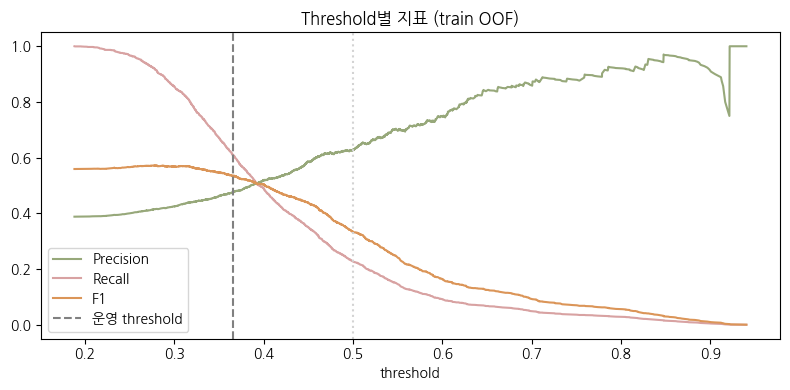

In [63]:
prec, rec, ths = precision_recall_curve(y_train, FINAL_OOF)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
share = np.array([(FINAL_OOF >= t).mean() for t in ths])
TH_F1 = float(ths[np.argmax(f1s)])                        # 제한 없는 F1 최대 (참고)
valid = share <= MAX_FLAG_SHARE
TH_OP = float(ths[valid][np.argmax(f1s[valid])])          # 운영 threshold

th_table = pd.DataFrame([{'threshold': t, **metrics_at(y_train, FINAL_OOF, t),
                          '결제 예상 비율': (FINAL_OOF >= t).mean()}
                         for t in sorted({0.3, 0.35, 0.4, 0.45, 0.5, round(TH_F1, 3), round(TH_OP, 3)})])
print(f'F1 최대 threshold(제한 없음) = {TH_F1:.3f} → 결제 예상 비율 {(FINAL_OOF >= TH_F1).mean():.1%}')
print(f'운영 threshold(비율 ≤ {MAX_FLAG_SHARE:.0%}) = {TH_OP:.3f} → 결제 예상 비율 {(FINAL_OOF >= TH_OP).mean():.1%}')
display(th_table.round(4))

plt.figure(figsize=(8, 4))
plt.plot(ths, prec[:-1], color=C_MAIN, label='Precision')
plt.plot(ths, rec[:-1], color=C_SUB, label='Recall')
plt.plot(ths, f1s, color=C_ACCENT, label='F1')
plt.axvline(TH_OP, ls='--', c='gray', label='운영 threshold'); plt.axvline(0.5, ls=':', c='lightgray')
plt.xlabel('threshold'); plt.legend(); plt.title('Threshold별 지표 (train OOF)'); plt.tight_layout(); plt.show()

## 5. Test 최종 평가 (1회)

In [64]:
def fit_member(name):
    m = make_model(name, best_feats[name], balanced=use_balanced[name]).set_params(**best_params[name])
    return m.fit(train[best_feats[name]], y_train)

fitted = {m: fit_member(m) for m in FINAL_MEMBERS}
member_test = {m: fitted[m].predict_proba(test[best_feats[m]])[:, 1] for m in FINAL_MEMBERS}

if FINAL_TYPE == 'stack':
    meta = LogisticRegression().fit(meta_X, y_train)
    test_prob = meta.predict_proba(np.column_stack([member_test[m] for m in FINAL_MEMBERS]))[:, 1]
else:
    test_prob = np.mean([member_test[m] for m in FINAL_MEMBERS], axis=0)

b1 = LogisticRegression(max_iter=1000).fit(train[['visit_days']], y_train)
b1_test = b1.predict_proba(test[['visit_days']])[:, 1]

test_result = {
    'dataset': DATASET, 'final_model': FINAL, 'n_test': len(test),
    'cv_auc': FINAL_CV['auc'], 'test_auc': roc_auc_score(y_test, test_prob),
    'B1_test_auc': roc_auc_score(y_test, b1_test),
    'threshold': TH_OP,
    **{f'{k}@0.5': v for k, v in metrics_at(y_test, test_prob, 0.5).items()},
    **{f'{k}@th': v for k, v in metrics_at(y_test, test_prob, TH_OP).items()},
}
display(pd.Series(test_result).to_frame('value'))

gap  = test_result['test_auc'] - test_result['cv_auc']
lift = test_result['test_auc'] - test_result['B1_test_auc']
print(f"CV {test_result['cv_auc']:.3f} → test {test_result['test_auc']:.3f} ({gap:+.3f})",
      f'⚠️ 차이가 {CV_TEST_GAP_WARN} 이상 → CV가 낙관적으로 추정됨' if -gap >= CV_TEST_GAP_WARN else '→ 안정적')
print(f"test 기준 B1 대비 {lift:+.3f}",
      '→ 기준선 초과' if lift >= MIN_GAIN else '→ 기준선과 차이 없음 (한계로 기록)')

,value
dataset,visit
final_model,CAT
n_test,1257
cv_auc,0.641391
test_auc,0.648227
B1_test_auc,0.591166
threshold,0.365881
precision@0.5,0.637755
recall@0.5,0.252016
f1@0.5,0.361272


CV 0.641 → test 0.648 (+0.007) → 안정적
test 기준 B1 대비 +0.057 → 기준선 초과


## 6. 모델 해석 (SHAP · Permutation)
- SHAP: 각 변수가 결제 확률을 얼마나 올리고/내렸는지 (범주형은 방향 없음)
- Permutation: 변수를 섞었을 때 **test AUC가 얼마나 떨어지는지** → 실제 성능 기여
- 두 방법에서 공통으로 상위인 변수만 핵심 신호로 해석한다. 인과가 아니라 **"~일수록 결제 확률이 높게 예측된다"**로 쓴다.

> ⚠️ **한계**: 상위 변수인 `last_visit_offset`, `visit_span`은 3일차 방문 여부와 연결된다. 결제 시점 정보가 없어 3일차 이용 중 일부는 결제 이후 이용일 수 있으므로, 이 변수들의 기여에는 결제 후 이용이 섞여 있을 가능성이 있다.

설명 대상: CatBoost


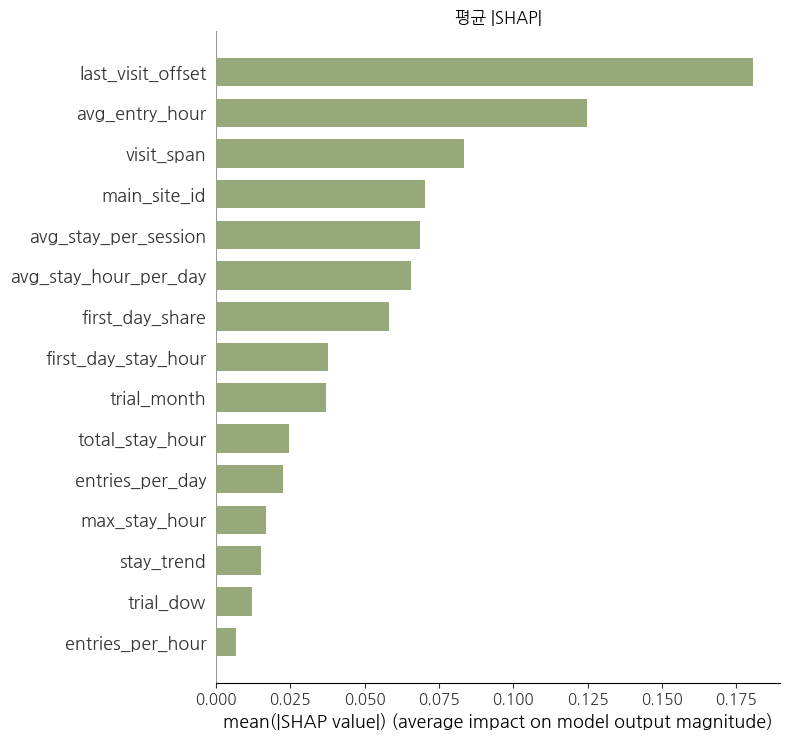

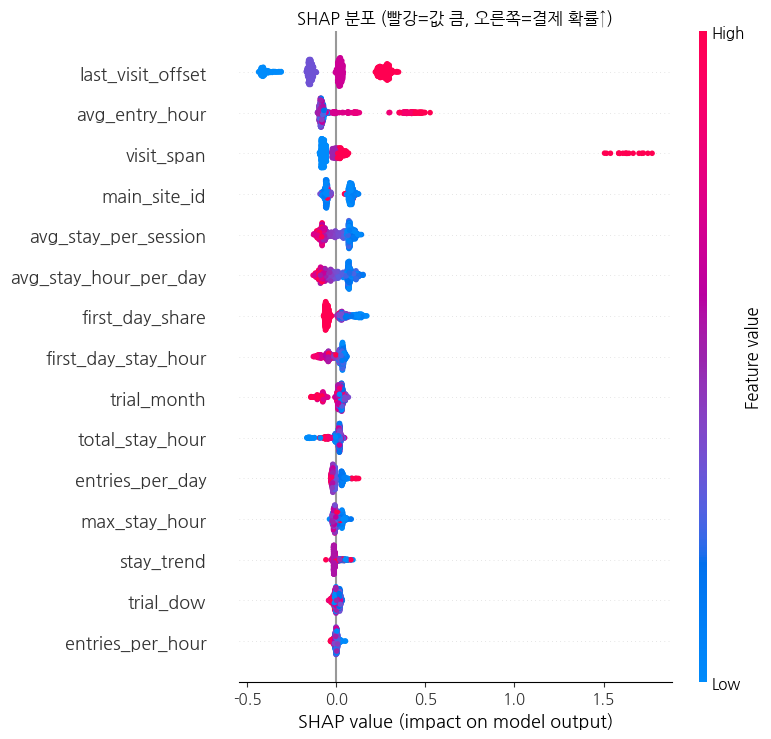

,mean_abs_shap,direction,해석
last_visit_offset,0.1806,1.0,값↑ → 결제 확률↑
avg_entry_hour,0.1248,1.0,값↑ → 결제 확률↑
visit_span,0.0833,1.0,값↑ → 결제 확률↑
main_site_id,0.0703,0.0,범주형 (방향 없음)
avg_stay_per_session,0.0685,-1.0,값↑ → 결제 확률↓
avg_stay_hour_per_day,0.0655,-1.0,값↑ → 결제 확률↓
first_day_share,0.0582,-1.0,값↑ → 결제 확률↓
first_day_stay_hour,0.0376,-1.0,값↑ → 결제 확률↓
trial_month,0.0370,0.0,범주형 (방향 없음)
total_stay_hour,0.0247,-1.0,값↑ → 결제 확률↓


In [65]:
import shap

explain_name = max(FINAL_MEMBERS, key=lambda m: r2_tuned[m]['auc'])
feats = best_feats[explain_name]
model = fitted[explain_name]
X_exp = test[feats].sample(min(800, len(test)), random_state=RANDOM_STATE)
print('설명 대상:', MODEL_NAMES[explain_name])

shap_tbl = None
if explain_name == 'LR':
    names = model.named_steps['prep'].get_feature_names_out()
    coef = pd.Series(model.named_steps['model'].coef_[0], index=names).sort_values(key=abs, ascending=False)
    display(coef.head(15).round(4).to_frame('표준화 계수 (+: 결제↑)'))
else:
    X_in = model.named_steps['prep'].transform(X_exp) if 'prep' in model.named_steps else X_exp
    X_in = pd.DataFrame(X_in, columns=feats)
    est = model.named_steps['model']
    est = getattr(est, 'model_', est)          # CatBoostWrapper면 내부 모델 사용
    sv = shap.TreeExplainer(est).shap_values(X_in)
    sv = sv[1] if isinstance(sv, list) else sv
    sv = sv[:, :, 1] if sv.ndim == 3 else sv

    shap.summary_plot(sv, X_in, plot_type='bar', max_display=15, show=False, color=C_MAIN)
    plt.title('평균 |SHAP|'); plt.tight_layout(); plt.show()
    shap.summary_plot(sv, X_in, max_display=15, show=False)
    plt.title('SHAP 분포 (빨강=값 큼, 오른쪽=결제 확률↑)'); plt.tight_layout(); plt.show()

    direction = []
    for i, c in enumerate(feats):
        if c in CAT_COLS or X_in[c].nunique() <= 1:
            direction.append(0)                # 범주형은 번호 크기에 방향이 없음
        else:
            direction.append(np.sign(np.corrcoef(X_in[c].fillna(-1), sv[:, i])[0, 1]))
    shap_tbl = pd.DataFrame({'mean_abs_shap': np.abs(sv).mean(axis=0), 'direction': direction},
                            index=feats).sort_values('mean_abs_shap', ascending=False)
    shap_tbl['해석'] = shap_tbl['direction'].map({1.0: '값↑ → 결제 확률↑', -1.0: '값↑ → 결제 확률↓'})
    shap_tbl.loc[shap_tbl.index.isin(CAT_COLS), '해석'] = '범주형 (방향 없음)'
    display(shap_tbl.head(15).round(4))

,내장 중요도(%),AUC 감소(평균),AUC 감소(표준편차),mean_abs_shap,SHAP 방향,test 기여
last_visit_offset,18.6233,0.0372,0.0098,0.1806,값↑ → 결제 확률↑,확인
visit_span,22.4119,0.0203,0.0053,0.0833,값↑ → 결제 확률↑,확인
avg_entry_hour,11.8728,0.0157,0.0063,0.1248,값↑ → 결제 확률↑,확인
main_site_id,5.4160,0.0080,0.0027,0.0703,범주형 (방향 없음),확인
first_day_share,5.4249,0.0069,0.0017,0.0582,값↑ → 결제 확률↓,확인
trial_month,3.9352,0.0063,0.0017,0.0370,범주형 (방향 없음),확인
avg_stay_hour_per_day,6.3451,0.0037,0.0024,0.0655,값↑ → 결제 확률↓,불확실
avg_stay_per_session,5.9302,0.0030,0.0023,0.0685,값↑ → 결제 확률↓,불확실
total_stay_hour,3.7336,0.0025,0.0018,0.0247,값↑ → 결제 확률↓,불확실
stay_trend,2.0268,0.0011,0.0012,0.0150,값↑ → 결제 확률↓,불확실


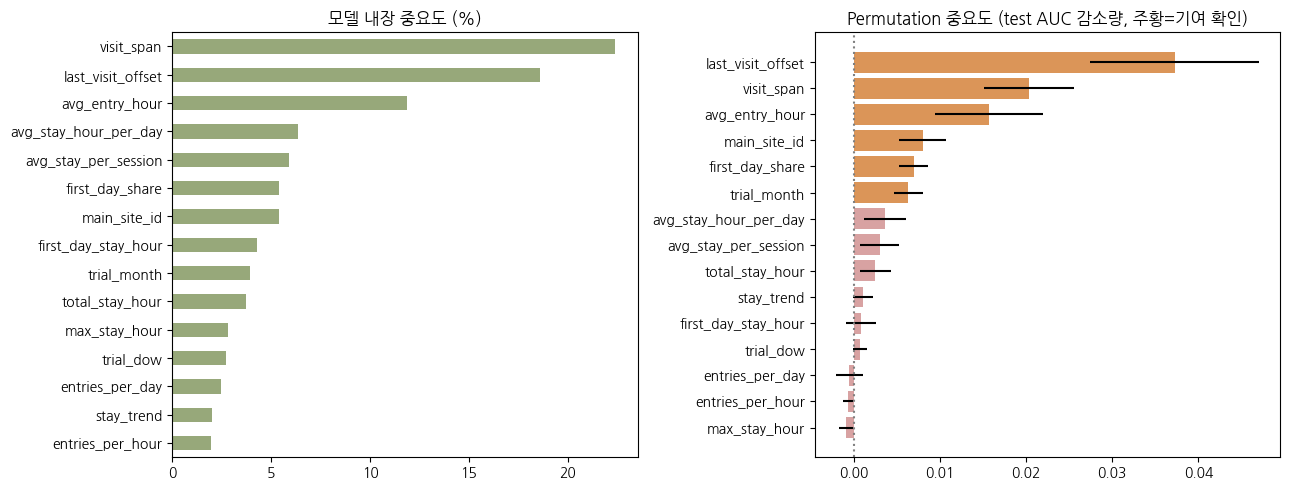

In [66]:
from sklearn.inspection import permutation_importance

builtin = get_importance(explain_name, model, feats)
builtin = builtin / builtin.sum() * 100
perm = permutation_importance(model, test[feats], y_test, scoring='roc_auc',
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

imp_tbl = pd.DataFrame({
    '내장 중요도(%)': builtin,
    'AUC 감소(평균)': perm.importances_mean,
    'AUC 감소(표준편차)': perm.importances_std,
}, index=feats)
if shap_tbl is not None:
    imp_tbl['mean_abs_shap'] = shap_tbl['mean_abs_shap']
    imp_tbl['SHAP 방향'] = shap_tbl['해석']
# 섞었을 때 AUC 감소가 표준편차의 2배 이상이면 test에서도 기여가 확인된 변수로 본다
imp_tbl['test 기여'] = np.where(imp_tbl['AUC 감소(평균)'] > 2 * imp_tbl['AUC 감소(표준편차)'], '확인', '불확실')
imp_tbl = imp_tbl.sort_values('AUC 감소(평균)', ascending=False)
display(imp_tbl.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
imp_tbl['내장 중요도(%)'].sort_values().plot.barh(ax=axes[0], color=C_MAIN)
axes[0].set_title('모델 내장 중요도 (%)')
s = imp_tbl.sort_values('AUC 감소(평균)')
axes[1].barh(s.index, s['AUC 감소(평균)'], xerr=s['AUC 감소(표준편차)'],
             color=np.where(s['test 기여'] == '확인', C_ACCENT, C_SUB))
axes[1].axvline(0, c='gray', ls=':')
axes[1].set_title('Permutation 중요도 (test AUC 감소량, 주황=기여 확인)')
plt.tight_layout(); plt.show()

## 7. 실험 기록 저장

In [67]:
log_df = pd.DataFrame(exp_log)
display(log_df[['stage', 'model', 'n_feat', 'auc', 'auc_std', 'precision', 'recall', 'f1', 'note']]
        .sort_values(['stage', 'auc'], ascending=[True, False]))

log_df.to_csv(OUT_DIR + f'experiment_log_{DATASET}.csv', index=False, encoding='utf-8-sig')
with open(OUT_DIR + f'test_result_{DATASET}.json', 'w', encoding='utf-8') as f:
    json.dump({**test_result, 'features': {m: best_feats[m] for m in FINAL_MEMBERS}},
              f, ensure_ascii=False, indent=2, default=str)
print('저장:', f'experiment_log_{DATASET}.csv', f'test_result_{DATASET}.json')

,stage,model,n_feat,auc,auc_std,precision,recall,f1,note
1,Baseline,B1_LR_visit_days,1.0,0.5637,0.0140,0.4976,0.0513,0.0930,
0,Baseline,B0_Dummy,0.0,0.5000,0.0000,0.0000,0.0000,0.0000,
5,R1_common,CAT,24.0,0.6417,0.0103,0.6057,0.2896,0.3918,
2,R1_common,LR,24.0,0.6318,0.0124,0.5814,0.2765,0.3748,
3,R1_common,RF,24.0,0.6301,0.0087,0.5548,0.3539,0.4322,
6,R1_common,LGBM,24.0,0.6253,0.0060,0.5462,0.3746,0.4444,
4,R1_common,XGB,24.0,0.6214,0.0071,0.5495,0.3519,0.4291,
13,R2_balanced,RF,25.0,0.6417,0.0142,0.5117,0.5163,0.5140,채택=False
15,R2_balanced,CAT,15.0,0.6408,0.0131,0.5044,0.5229,0.5135,채택=False
16,R2_balanced,LGBM,25.0,0.6368,0.0149,0.4936,0.5425,0.5169,채택=False


저장: experiment_log_visit.csv test_result_visit.json


## 8. 단계별 성능 변화

,단계,모델,AUC,결과,B1 대비
0,B0 찍기,Dummy,0.5000,기준선,-0.0637
1,B1 방문일수,로지스틱 회귀 (피처 1개),0.5637,기준선,0.0000
2,R1 공통 피처,CatBoost (24개),0.6417,채택,0.0780
3,R2 피처 선택,CatBoost (15개),0.6393,유지,0.0756
4,R2 튜닝,CatBoost,0.6414,유지,0.0777
5,R2 클래스 가중치,랜덤 포레스트,0.6417,미채택,0.0780
6,R3 앙상블,Vote(CAT+LGBM),0.6443,미채택,0.0805
7,최종 (CV),CatBoost,0.6414,최종,0.0777
8,최종 (test),CatBoost,0.6482,실전,0.0845


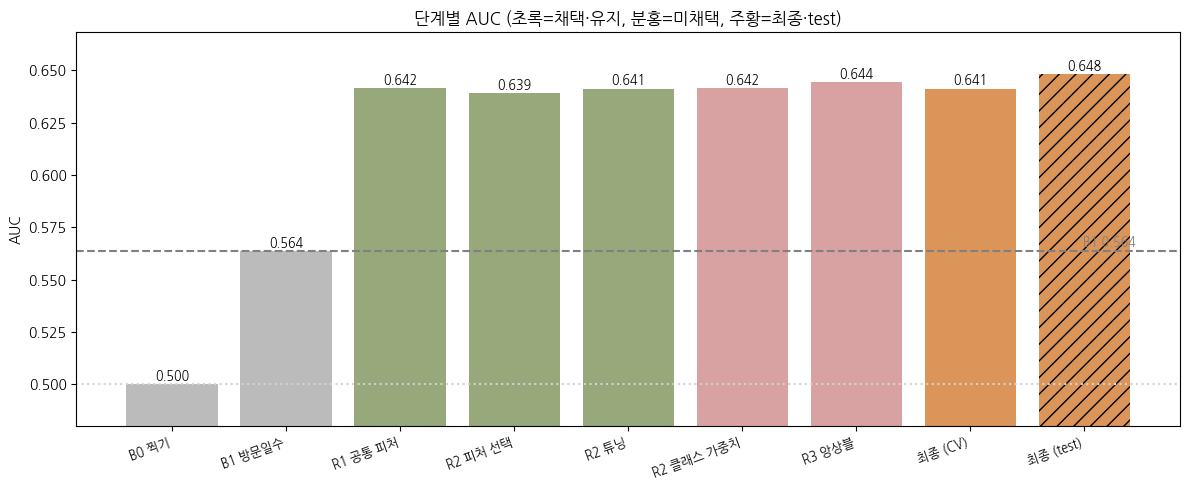

[결과 요약]
- 행동 변수 추가 (B1 → R1): 0.564 → 0.642 (+0.078)
- 피처 선택·튜닝 (R1 → R2): 0.642 → 0.641 → 변화 없음, 피처 24개 → 15개로 축소
- 클래스 가중치: AUC +0.0011 → 미채택
- 앙상블: 최고 단일 대비 +0.0029 → 미채택
- 최종 모델: CatBoost (CV 0.641) — 앙상블 이득 0.005 미만 → 동점 그룹(1위와 차이 < 0.005) 중 표준편차 최소
- test: 0.648 (CV 대비 +0.007, B1 대비 +0.057)


In [68]:
sel_auc  = {m: float(r2_select[m].loc[r2_select[m]['k'] == len(best_feats[m]), 'auc'].iloc[0]) for m in MODELS}
sel_best = max(sel_auc, key=sel_auc.get)
r1_best  = max(r1, key=lambda m: r1[m]['auc'])
tun_best = max(r2_tuned, key=lambda m: r2_tuned[m]['auc'])
bal      = log_df[log_df['stage'] == 'R2_balanced'].sort_values('auc', ascending=False).iloc[0]
bal_gain = bal['auc'] - r2_tuned[bal['model']]['auc']
ens_key  = max([k for k, v in candidates.items() if v[1] != 'single'], key=lambda k: candidates[k][2]['auc'])
ens_gain = candidates[ens_key][2]['auc'] - BEST_SINGLE_AUC

steps = [
    ('B0 찍기',        'Dummy',                                                   0.5,                           '기준선'),
    ('B1 방문일수',    '로지스틱 회귀 (피처 1개)',                                  B1_AUC,                        '기준선'),
    ('R1 공통 피처',   f'{MODEL_NAMES[r1_best]} ({len(COMMON)}개)',                r1[r1_best]['auc'],            '채택'),
    ('R2 피처 선택',   f'{MODEL_NAMES[sel_best]} ({len(best_feats[sel_best])}개)', sel_auc[sel_best],             '유지'),
    ('R2 튜닝',        f'{MODEL_NAMES[tun_best]}',                                 r2_tuned[tun_best]['auc'],     '유지'),
    ('R2 클래스 가중치', f"{MODEL_NAMES[bal['model']]}",                            bal['auc'],                    '채택' if bal_gain >= MIN_GAIN else '미채택'),
    ('R3 앙상블',      ens_key,                                                   candidates[ens_key][2]['auc'], '채택' if FINAL_TYPE != 'single' else '미채택'),
    ('최종 (CV)',      FINAL_NAME,                                                FINAL_CV['auc'],               '최종'),
    ('최종 (test)',    FINAL_NAME,                                                test_result['test_auc'],       '실전'),
]
step_tbl = pd.DataFrame(steps, columns=['단계', '모델', 'AUC', '결과'])
step_tbl['B1 대비'] = step_tbl['AUC'] - B1_AUC
display(step_tbl.round(4))

# 유지 = 개선 기준(+0.005) 미달이지만 성능이 같아 더 적은 피처 버전을 유지
color_map = {'기준선': '#BBBBBB', '채택': C_MAIN, '유지': C_MAIN, '미채택': C_SUB, '최종': C_ACCENT, '실전': C_ACCENT}
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(step_tbl)), step_tbl['AUC'], color=step_tbl['결과'].map(color_map))
bars[-1].set_hatch('//')
ax.axhline(0.5, ls=':', c='lightgray')
ax.axhline(B1_AUC, ls='--', c='gray'); ax.text(len(step_tbl) - 0.55, B1_AUC + 0.001, f'B1 {B1_AUC:.3f}', ha='right', va='bottom', fontsize=9, color='gray')
for b, v in zip(bars, step_tbl['AUC']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)
ax.set_xticks(range(len(step_tbl)))
ax.set_xticklabels(step_tbl['단계'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.48, step_tbl['AUC'].max() + 0.02)
ax.set_ylabel('AUC')
ax.set_title('단계별 AUC (초록=채택·유지, 분홍=미채택, 주황=최종·test)')
plt.tight_layout(); plt.show()

print('[결과 요약]')
print(f"- 행동 변수 추가 (B1 → R1): {B1_AUC:.3f} → {r1[r1_best]['auc']:.3f} ({r1[r1_best]['auc'] - B1_AUC:+.3f})")
print(f"- 피처 선택·튜닝 (R1 → R2): {r1[r1_best]['auc']:.3f} → {r2_tuned[tun_best]['auc']:.3f} → 변화 없음, 피처 {len(COMMON)}개 → {len(best_feats[tun_best])}개로 축소")
print(f"- 클래스 가중치: AUC {bal_gain:+.4f} → {'채택' if bal_gain >= MIN_GAIN else '미채택'}")
print(f"- 앙상블: 최고 단일 대비 {ens_gain:+.4f} → {'채택' if FINAL_TYPE != 'single' else '미채택'}")
print(f"- 최종 모델: {FINAL_NAME} (CV {FINAL_CV['auc']:.3f}) — {reason}")
print(f"- test: {test_result['test_auc']:.3f} (CV 대비 {gap:+.3f}, B1 대비 {lift:+.3f})")

## 9. 최종 모델 성적표 (test)
> Accuracy는 전원 '미결제'로 찍어도 비슷하게 나오므로 참고용이다. 성능은 **ROC-AUC, Precision, Recall** 중심으로 본다.

In [69]:
rand_prec = y_test.mean()   # 무작위로 골랐을 때 결제자 비율 (= test 결제율)
report = pd.DataFrame([
    ['ROC-AUC',   test_result['test_auc'],     f"CV {FINAL_CV['auc']:.3f} → test {test_result['test_auc']:.3f}"],
    ['B1 AUC',    test_result['B1_test_auc'],  f"최종 모델이 {lift:+.3f}"],
    ['Threshold', TH_OP,                       f"결제 예상 비율 ≤ {MAX_FLAG_SHARE:.0%}에서 F1 최대"],
    ['Precision', test_result['precision@th'], f"무작위 {rand_prec:.3f} 대비 {test_result['precision@th'] / rand_prec:.2f}배"],
    ['Recall',    test_result['recall@th'],    f"결제자 10명 중 {test_result['recall@th'] * 10:.1f}명 탐지"],
    ['F1',        test_result['f1@th'],        ''],
    ['Accuracy',  test_result['accuracy@th'],  f"참고용 (전원 미결제로 예측 시 {1 - rand_prec:.3f})"],
], columns=['지표', '값', '비고'])
report['값'] = report['값'].astype(float).round(3)
print(f'최종 모델: {FINAL_NAME} / test {len(test):,}명')
display(report)

pred = (test_prob >= TH_OP).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
cm = pd.DataFrame([[tp, fp], [fn, tn]], index=['결제 예측', '미결제 예측'], columns=['실제 결제', '실제 미결제'])
display(cm)
print(f"결제 예측 {tp + fp}명 중 실제 결제 {tp}명 (Precision {tp / (tp + fp):.1%})")
print(f"실제 결제 {tp + fn}명 중 탐지 {tp}명 (Recall {tp / (tp + fn):.1%}) / 놓침 {fn}명 / 오탐 {fp}명")

최종 모델: CatBoost / test 1,257명


,지표,값,비고
0,ROC-AUC,0.648,CV 0.641 → test 0.648
1,B1 AUC,0.591,최종 모델이 +0.057
2,Threshold,0.366,결제 예상 비율 ≤ 50%에서 F1 최대
3,Precision,0.501,무작위 0.395 대비 1.27배
4,Recall,0.665,결제자 10명 중 6.7명 탐지
5,F1,0.571,
6,Accuracy,0.606,참고용 (전원 미결제로 예측 시 0.605)


,실제 결제,실제 미결제
결제 예측,330,329
미결제 예측,166,432


결제 예측 659명 중 실제 결제 330명 (Precision 50.1%)
실제 결제 496명 중 탐지 330명 (Recall 66.5%) / 놓침 166명 / 오탐 329명
